## 01 - Project Overview

The objective of this project is to build a small end-to-end data engineering pipeline that ingests energy consumption data, performs data quality checks and cleaning, transforms and models the data, and produces useful analytics and visualisations.


## 02 - Generate Raw Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Select a seed to get reproducible data
np.random.seed(42)

# Create hourly timestamps
dates = pd.date_range(start="2026-01-01", end="2026-06-30 23:00", freq="h")

# Generate 10 building IDs and 50 sensor IDs
building_id = [f"B{i:02d}" for i in range(1, 11)]
sensor_id = [f"S{i:03d}" for i in range(1, 51)]

# Create every combination of timestamp and sensor
df = pd.MultiIndex.from_product(
    [dates, sensor_id],
    names=["timestamp", "sensor_id"]
).to_frame(index=False)

# Assign each sensor to a building
df["building_id"] = df["sensor_id"].str.extract(r"S(\d+)")[0].astype(int).sub(1).floordiv(5).add(1).map(lambda x: f"B{x:02d}")

# Generate sensor measurements
df["voltage"] = np.random.uniform(210, 250, len(df))
df["current"] = np.random.uniform(0, 20, len(df))
df["power_factor"] = np.random.uniform(0.7, 1.0, len(df))
df["temperature"] = np.random.uniform(-10, 30, len(df))

# Calculate power in kW
df["power_kw"] = (df["voltage"] * df["current"] * df["power_factor"]) / 1000

# Calculate hourly energy consumption in kWh
df["energy_kwh"] = df["power_kw"] * 1

In [2]:
# Introduce missing values
df.loc[df.sample(frac=0.01).index, "energy_kwh"] = np.nan

# Introduce duplicates
duplicates = df.sample(frac=0.005, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

# Introduce invalid energy consumption values
df.loc[df.sample(frac=0.002).index, "energy_kwh"] = -5

# Introduce extreme voltage values
n_extreme = max(1, int(len(df) * 0.002))
extreme_voltage_indices = df.sample(n=n_extreme, random_state=42).index
df.loc[extreme_voltage_indices, "voltage"] = np.random.uniform(500, 700, size=n_extreme)

# Introduce extreme energy consumption values
n_extreme_energy = max(1, int(len(df) * 0.002))
extreme_energy_indices = df.sample(n=n_extreme_energy, random_state=43).index
df.loc[extreme_energy_indices, "energy_kwh"] = np.random.uniform(6, 7, size=n_extreme_energy)

# Introduce missing timestamps
df.loc[df.sample(frac=0.01).index, "timestamp"] = np.nan

In [3]:
# Checks to verify data-generation code has worked
print("Rows:", len(df))
print("Unique index:", df.index.is_unique)
print("Extreme voltage rows:", (df["voltage"] > 500).sum())
print("Extreme energy rows:", (df["energy_kwh"] > 5).sum())
print("Missing timestamps:", df["timestamp"].isna().sum())
print("Missing energy:", df["energy_kwh"].isna().sum())
print("Negative energy:", (df["energy_kwh"] < 0).sum())

df

Rows: 218286
Unique index: True
Extreme voltage rows: 436
Extreme energy rows: 436
Missing timestamps: 2183
Missing energy: 2175
Negative energy: 436


,timestamp,sensor_id,building_id,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,2026-01-01 00:00:00,S001,B01,224.981605,4.976163,0.981287,22.265139,1.098596,1.098596
1,2026-01-01 00:00:00,S002,B01,248.028572,4.191213,0.761185,16.145604,0.791283,0.791283
2,2026-01-01 00:00:00,S003,B01,239.279758,10.017032,0.735806,1.135156,1.763634,1.763634
3,2026-01-01 00:00:00,S004,B01,233.946339,11.690004,0.747685,-0.073898,2.044795,2.044795
4,2026-01-01 00:00:00,S005,B01,216.240746,5.435727,0.826808,14.527551,0.971852,0.971852
...,...,...,...,...,...,...,...,...,...
218281,2026-01-11 11:00:00,S043,B09,225.506396,10.138747,0.953290,-3.690969,2.179556,2.179556
218282,2026-06-24 12:00:00,S031,B07,221.671726,8.606510,0.763930,19.071226,1.457441,1.457441
218283,2026-01-15 20:00:00,S033,B07,210.398145,13.476951,0.705658,-8.943785,2.000911,2.000911
218284,2026-06-12 06:00:00,S026,B06,227.678267,3.102065,0.752226,18.711562,0.531277,0.531277


## 03 - Data Quality Checks

03.1 How Many Records Arrived?

In [4]:
-- Check how many records arrived
SELECT COUNT(*)
FROM df;

,count_star()
0,218286


03.2 Are There Duplicate Records?

In [5]:
-- Check for duplicate records
SELECT timestamp, sensor_id, COUNT(*) AS record_count
FROM df
WHERE timestamp IS NOT NULL
GROUP BY timestamp, sensor_id
HAVING COUNT(*) > 1;

,timestamp,sensor_id,record_count
0,2026-01-01 04:00:00+00:00,S022,2
1,2026-01-02 05:00:00+00:00,S050,2
2,2026-01-02 23:00:00+00:00,S018,2
3,2026-01-04 13:00:00+00:00,S049,2
4,2026-01-05 04:00:00+00:00,S003,2
...,...,...,...
1053,2026-06-28 14:00:00+00:00,S049,2
1054,2026-06-29 21:00:00+00:00,S011,2
1055,2026-06-30 05:00:00+00:00,S011,2
1056,2026-06-30 16:00:00+00:00,S025,2


03.3 Are There Invalid Energy Readings?

In [6]:
-- Check for invalid energy readings
SELECT *
FROM df
WHERE energy_kwh < 0 OR energy_kwh > 5;

,timestamp,sensor_id,building_id,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,2026-01-01 02:00:00+00:00,S008,B02,240.222046,3.986220,0.805368,9.160860,0.771202,-5.000000
1,2026-01-01 19:00:00+00:00,S003,B01,217.014851,10.833242,0.805716,28.659219,1.894218,6.079011
2,2026-01-01 23:00:00+00:00,S046,B10,244.861472,1.864984,0.713592,10.007527,0.325871,6.144826
3,2026-01-02 05:00:00+00:00,S025,B05,223.081326,1.030557,0.783652,24.417342,0.180160,6.858742
4,2026-01-03 00:00:00+00:00,S017,B04,225.368269,17.702621,0.721449,28.409153,2.878300,6.576735
...,...,...,...,...,...,...,...,...,...
867,2026-06-30 13:00:00+00:00,S038,B08,236.753555,9.252808,0.717577,19.912845,1.571949,6.066687
868,NaT,S034,B07,241.207224,3.618019,0.903107,1.032899,0.788135,6.392546
869,2026-01-17 22:00:00+00:00,S048,B10,214.510822,10.574533,0.932840,5.683425,2.116009,6.917160
870,2026-05-29 22:00:00+00:00,S015,B03,236.687658,18.984224,0.782786,-0.082132,3.517318,-5.000000


03.4 Are There Invalid Voltage Readings?

In [7]:
-- Check for invalid voltage readings
SELECT *
FROM df
WHERE voltage < 200 OR voltage > 250;

,timestamp,sensor_id,building_id,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,2026-01-01 04:00:00+00:00,S009,B02,523.216031,16.343696,0.960753,-9.165504,3.300654,3.300654
1,2026-01-01 04:00:00+00:00,S012,B03,555.336364,16.466630,0.700699,4.826154,2.742340,2.742340
2,2026-01-01 10:00:00+00:00,S012,B03,680.197066,14.998690,0.719841,-5.690258,2.447927,2.447927
3,2026-01-01 16:00:00+00:00,S010,B02,663.321204,14.628931,0.947584,-1.053642,2.973839,2.973839
4,2026-01-01 18:00:00+00:00,S001,B01,648.466890,2.054258,0.796882,29.310148,0.357383,0.357383
...,...,...,...,...,...,...,...,...,...
431,2026-06-28 17:00:00+00:00,S004,B01,619.538737,4.795436,0.876602,-1.829476,0.974695,0.974695
432,2026-06-29 16:00:00+00:00,S032,B07,686.520942,2.271064,0.969548,28.828948,0.507827,0.507827
433,2026-06-30 00:00:00+00:00,S022,B05,616.452875,1.877658,0.780329,7.757904,0.308979,0.308979
434,2026-06-30 23:00:00+00:00,S047,B10,550.340841,3.363932,0.950302,-5.092782,0.753164,0.753164


03.5 Are There Missing Values?

In [8]:
-- Check for missing values
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE timestamp IS NULL) AS missing_timestamp,
    COUNT(*) FILTER (WHERE sensor_id IS NULL) AS missing_sensor_id,
    COUNT(*) FILTER (WHERE building_id IS NULL) AS missing_building_id,
	COUNT(*) FILTER (WHERE energy_kwh IS NULL) AS missing_energy_kwh,
    COUNT(*) FILTER (WHERE voltage IS NULL) AS missing_voltage,
    COUNT(*) FILTER (WHERE current IS NULL) AS missing_current,
    COUNT(*) FILTER (WHERE power_factor IS NULL) AS missing_power_factor,
    COUNT(*) FILTER (WHERE temperature IS NULL) AS missing_temperature,
    COUNT(*) FILTER (WHERE power_kw IS NULL) AS missing_power_kw
FROM df;

,total_rows,missing_timestamp,missing_sensor_id,missing_building_id,missing_energy_kwh,missing_voltage,missing_current,missing_power_factor,missing_temperature,missing_power_kw
0,218286,2183,0,0,2175,0,0,0,0,0


03.6 Are There Invalid Sensor or Building IDs?

In [9]:
-- Check for invalid sensor or building IDs
SELECT *
FROM df
WHERE sensor_id NOT LIKE 'S0__' OR building_id NOT LIKE 'B__';

,timestamp,sensor_id,building_id,voltage,current,power_factor,temperature,power_kw,energy_kwh


## 04 - Data Cleaning

04.1 Create a Cleaning Copy and Record the Starting Quality

In [10]:
# Create a copy of the raw data for cleaning to keep the original df unchanged
df_clean = df.copy().reset_index(drop=True)

# Convert timestamp to datetime
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"], errors="coerce")

# Ensure ID columns use string data type
df_clean["sensor_id"] = df_clean["sensor_id"].astype("string")
df_clean["building_id"] = df_clean["building_id"].astype("string")

# Ensure measurement columns are numeric
numeric_columns = [
    "voltage",
    "current",
    "power_factor",
    "temperature",
    "power_kw",
    "energy_kwh"
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

# Record data quality before cleaning
quality_before = {
    "Total rows": len(df_clean),

    "Missing timestamps":
        df_clean["timestamp"].isna().sum(),

    "Missing energy readings":
        df_clean["energy_kwh"].isna().sum(),

    "Duplicate timestamp/sensor records":
        df_clean.loc[df_clean["timestamp"].notna()]
        .duplicated(subset=["timestamp", "sensor_id"])
        .sum(),

    "Invalid energy readings":
        (
            (df_clean["energy_kwh"] < 0) |
            (df_clean["energy_kwh"] > 5)
        ).sum(),

    "Invalid voltage readings":
        (
            (df_clean["voltage"] < 200) |
            (df_clean["voltage"] > 250)
        ).sum()
}

pd.Series(quality_before, name="Before Cleaning")

Total rows                            218286
Missing timestamps                      2183
Missing energy readings                 2175
Duplicate timestamp/sensor records      1058
Invalid energy readings                  872
Invalid voltage readings                 436
Name: Before Cleaning, dtype: int64

04.2 Remove Records Without Critical Identifiers

In [11]:
# Count rows with missing critical identifiers
missing_key_rows = (
    df_clean["timestamp"].isna() |
    df_clean["sensor_id"].isna()
).sum()

# Remove rows where timestamp or sensor_id is missing
df_clean = df_clean.dropna(
    subset=["timestamp", "sensor_id"]
).copy()

print("Rows removed due to missing timestamp/sensor ID:", missing_key_rows)

Rows removed due to missing timestamp/sensor ID: 2183


04.3 Remove Invalid Sensor IDs

In [12]:
# Create list of valid sensor IDs
valid_sensor_ids = [f"S{i:03d}" for i in range(1, 51)]

# Identify invalid sensor IDs
invalid_sensor_rows = (~df_clean["sensor_id"].isin(valid_sensor_ids)).sum()

# Keep only valid sensor IDs
df_clean = df_clean[
    df_clean["sensor_id"].isin(valid_sensor_ids)
].copy()

print("Rows removed due to invalid sensor IDs:", invalid_sensor_rows)

Rows removed due to invalid sensor IDs: 0


04.4 Rebuild Building IDs From Sensor IDs

In [13]:
# Extract sensor number
sensor_number = (
    df_clean["sensor_id"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

# Rebuild building ID from sensor ID
df_clean["building_id"] = (
    sensor_number
    .sub(1)
    .floordiv(5)
    .add(1)
    .map(lambda x: f"B{x:02d}")
)

04.5 Remove Duplicate Readings

In [14]:
# Count duplicate timestamp/sensor records
duplicate_rows = df_clean.duplicated(
    subset=["timestamp", "sensor_id"]
).sum()

# Remove duplicate readings
df_clean = df_clean.drop_duplicates(
    subset=["timestamp", "sensor_id"],
    keep="first"
).copy()

print("Duplicate rows removed:", duplicate_rows)

Duplicate rows removed: 1058


04.6 Identify Invalid Measurement Values

In [15]:
# Define valid measurement ranges
valid_ranges = {
    "voltage": (200, 250),
    "current": (0, 20),
    "power_factor": (0.7, 1.0),
    "temperature": (-10, 30)
}

# Replace invalid measurement values with NaN
for column, (minimum, maximum) in valid_ranges.items():
    invalid_mask = ~df_clean[column].between(
        minimum,
        maximum
    )
    df_clean.loc[
        invalid_mask,
        column
    ] = np.nan

04.7 Fill Missing Measurement Values

In [16]:
# Measurement columns to repair
measurement_columns = [
    "voltage",
    "current",
    "power_factor",
    "temperature"
]

for column in measurement_columns:

    # Calculate median value for each sensor
    sensor_median = (
        df_clean
        .groupby("sensor_id")[column]
        .transform("median")
    )

    # Fill missing values using that sensor's median
    df_clean[column] = (
        df_clean[column]
        .fillna(sensor_median)
    )

    # Fallback to overall median if necessary
    df_clean[column] = (
        df_clean[column]
        .fillna(df_clean[column].median())
    )

04.8 Recalculate Power

In [17]:
# Recalculate power using cleaned measurements

df_clean["power_kw"] = (
    df_clean["voltage"]
    * df_clean["current"]
    * df_clean["power_factor"]
) / 1000

04.9 Recalculate Energy Consumption

In [18]:
# Recalculate hourly energy consumption

df_clean["energy_kwh"] = (
    df_clean["power_kw"] * 1
)

04.10 Sort and Reset the Cleaned Dataset

In [19]:
# Sort records into chronological sensor order
df_clean = (
    df_clean
    .sort_values(
        by=["timestamp", "sensor_id"]
    )
    .reset_index(drop=True)
)

04.11 Validate the Cleaned Dataset

In [20]:
# Validate cleaned data

quality_after = {
    "Total rows": len(df_clean),

    "Missing timestamps":
        df_clean["timestamp"].isna().sum(),

    "Missing values":
        df_clean.isna().sum().sum(),

    "Duplicate timestamp/sensor records":
        df_clean.duplicated(
            subset=["timestamp", "sensor_id"]
        ).sum(),

    "Invalid voltage readings":
        (
            (df_clean["voltage"] < 200) |
            (df_clean["voltage"] > 250)
        ).sum(),

    "Invalid current readings":
        (
            (df_clean["current"] < 0) |
            (df_clean["current"] > 20)
        ).sum(),

    "Invalid power factor readings":
        (
            (df_clean["power_factor"] < 0.7) |
            (df_clean["power_factor"] > 1)
        ).sum(),

    "Invalid temperature readings":
        (
            (df_clean["temperature"] < -10) |
            (df_clean["temperature"] > 30)
        ).sum(),

    "Invalid energy readings":
        (
            (df_clean["energy_kwh"] < 0) |
            (df_clean["energy_kwh"] > 5)
        ).sum()
}

pd.Series(
    quality_after,
    name="After Cleaning"
)

Total rows                            215045
Missing timestamps                         0
Missing values                             0
Duplicate timestamp/sensor records         0
Invalid voltage readings                   0
Invalid current readings                   0
Invalid power factor readings              0
Invalid temperature readings               0
Invalid energy readings                    0
Name: After Cleaning, dtype: int64

04.12 Compare Before and After Cleaning

In [21]:
# Compare data quality before and after cleaning

cleaning_comparison = pd.DataFrame({
    "Before Cleaning": {
        "Missing timestamps":
            quality_before["Missing timestamps"],

        "Missing energy readings":
            quality_before["Missing energy readings"],

        "Duplicate records":
            quality_before["Duplicate timestamp/sensor records"],

        "Invalid energy readings":
            quality_before["Invalid energy readings"],

        "Invalid voltage readings":
            quality_before["Invalid voltage readings"]
    },

    "After Cleaning": {
        "Missing timestamps":
            df_clean["timestamp"].isna().sum(),

        "Missing energy readings":
            df_clean["energy_kwh"].isna().sum(),

        "Duplicate records":
            df_clean.duplicated(
                subset=["timestamp", "sensor_id"]
            ).sum(),

        "Invalid energy readings":
            (
                (df_clean["energy_kwh"] < 0) |
                (df_clean["energy_kwh"] > 5)
            ).sum(),

        "Invalid voltage readings":
            (
                (df_clean["voltage"] < 200) |
                (df_clean["voltage"] > 250)
            ).sum()
    }
})

cleaning_comparison

,Before Cleaning,After Cleaning
Missing timestamps,2183,0
Missing energy readings,2175,0
Duplicate records,1058,0
Invalid energy readings,872,0
Invalid voltage readings,436,0


04.13 Show New Table

In [22]:
df_clean

,timestamp,sensor_id,building_id,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,2026-01-01 00:00:00,S001,B01,224.981605,4.976163,0.981287,22.265139,1.098596,1.098596
1,2026-01-01 00:00:00,S002,B01,248.028572,4.191213,0.761185,16.145604,0.791283,0.791283
2,2026-01-01 00:00:00,S003,B01,239.279758,10.017032,0.735806,1.135156,1.763634,1.763634
3,2026-01-01 00:00:00,S004,B01,233.946339,11.690004,0.747685,-0.073898,2.044795,2.044795
4,2026-01-01 00:00:00,S005,B01,216.240746,5.435727,0.826808,14.527551,0.971852,0.971852
...,...,...,...,...,...,...,...,...,...
215040,2026-06-30 23:00:00,S046,B10,232.551174,9.221653,0.988085,24.583249,2.118954,2.118954
215041,2026-06-30 23:00:00,S047,B10,229.652629,3.363932,0.950302,-5.092782,0.734142,0.734142
215042,2026-06-30 23:00:00,S048,B10,217.463501,15.326987,0.858075,19.912524,2.860015,2.860015
215043,2026-06-30 23:00:00,S049,B10,239.450319,17.204400,0.971988,3.316911,4.004201,4.004201


## 05 - Data Modelling

05.1 Create Building Dimension

In [23]:
# Create building dimension

dim_building = (
    df_clean[["building_id"]]
    .drop_duplicates()
    .sort_values("building_id")
    .reset_index(drop=True)
)

# Create surrogate primary key
dim_building.insert(
    0,
    "building_key",
    range(1, len(dim_building) + 1)
)

dim_building

,building_key,building_id
0,1,B01
1,2,B02
2,3,B03
3,4,B04
4,5,B05
5,6,B06
6,7,B07
7,8,B08
8,9,B09
9,10,B10


05.2 Create Sensor Dimension

In [24]:
# Create sensor dimension

dim_sensor = (
    df_clean[
        ["sensor_id", "building_id"]
    ]
    .drop_duplicates()
    .sort_values("sensor_id")
    .reset_index(drop=True)
)

# Add building surrogate key
dim_sensor = dim_sensor.merge(
    dim_building,
    on="building_id",
    how="left"
)

# Create sensor surrogate primary key
dim_sensor.insert(
    0,
    "sensor_key",
    range(1, len(dim_sensor) + 1)
)

# Arrange columns
dim_sensor = dim_sensor[
    [
        "sensor_key",
        "sensor_id",
        "building_key",
        "building_id"
    ]
]

dim_sensor

,sensor_key,sensor_id,building_key,building_id
0,1,S001,1,B01
1,2,S002,1,B01
2,3,S003,1,B01
3,4,S004,1,B01
4,5,S005,1,B01
5,6,S006,2,B02
6,7,S007,2,B02
7,8,S008,2,B02
8,9,S009,2,B02
9,10,S010,2,B02


05.3 Create Date Dimension

In [25]:
# Create date dimension

dim_date = pd.DataFrame({
    "date": (
        df_clean["timestamp"]
        .dt.normalize()
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )
})

# Create YYYYMMDD date key
dim_date["date_key"] = (
    dim_date["date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Add useful date attributes
dim_date["year"] = dim_date["date"].dt.year
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.month_name()
dim_date["day"] = dim_date["date"].dt.day
dim_date["day_name"] = dim_date["date"].dt.day_name()
dim_date["week_of_year"] = (
    dim_date["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

dim_date["is_weekend"] = (
    dim_date["date"]
    .dt.dayofweek >= 5
)

# Put primary key first
dim_date = dim_date[
    [
        "date_key",
        "date",
        "year",
        "quarter",
        "month",
        "month_name",
        "day",
        "day_name",
        "week_of_year",
        "is_weekend"
    ]
]

dim_date.head()

,date_key,date,year,quarter,month,month_name,day,day_name,week_of_year,is_weekend
0,20260101,2026-01-01,2026,1,1,January,1,Thursday,1,False
1,20260102,2026-01-02,2026,1,1,January,2,Friday,1,False
2,20260103,2026-01-03,2026,1,1,January,3,Saturday,1,True
3,20260104,2026-01-04,2026,1,1,January,4,Sunday,1,True
4,20260105,2026-01-05,2026,1,1,January,5,Monday,2,False


05.4 Create Fact Table

In [26]:
# Create fact table from cleaned data

fact_energy_readings = df_clean.copy()

# Create foreign key for date dimension
fact_energy_readings["date_key"] = (
    fact_energy_readings["timestamp"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

# Extract hour for hourly analysis
fact_energy_readings["hour"] = (
    fact_energy_readings["timestamp"]
    .dt.hour
)

# Add sensor surrogate key
fact_energy_readings = (
    fact_energy_readings
    .merge(
        dim_sensor[
            ["sensor_id", "sensor_key"]
        ],
        on="sensor_id",
        how="left"
    )
)

# Add building surrogate key
fact_energy_readings = (
    fact_energy_readings
    .merge(
        dim_building[
            ["building_id", "building_key"]
        ],
        on="building_id",
        how="left"
    )
)

# Create fact table primary key
fact_energy_readings.insert(
    0,
    "reading_id",
    range(1, len(fact_energy_readings) + 1)
)

# Arrange fact table columns
fact_energy_readings = fact_energy_readings[
    [
        "reading_id",
        "timestamp",
        "date_key",
        "hour",
        "sensor_key",
        "building_key",
        "voltage",
        "current",
        "power_factor",
        "temperature",
        "power_kw",
        "energy_kwh"
    ]
]

fact_energy_readings

,reading_id,timestamp,date_key,hour,sensor_key,building_key,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,1,2026-01-01 00:00:00,20260101,0,1,1,224.981605,4.976163,0.981287,22.265139,1.098596,1.098596
1,2,2026-01-01 00:00:00,20260101,0,2,1,248.028572,4.191213,0.761185,16.145604,0.791283,0.791283
2,3,2026-01-01 00:00:00,20260101,0,3,1,239.279758,10.017032,0.735806,1.135156,1.763634,1.763634
3,4,2026-01-01 00:00:00,20260101,0,4,1,233.946339,11.690004,0.747685,-0.073898,2.044795,2.044795
4,5,2026-01-01 00:00:00,20260101,0,5,1,216.240746,5.435727,0.826808,14.527551,0.971852,0.971852
...,...,...,...,...,...,...,...,...,...,...,...,...
215040,215041,2026-06-30 23:00:00,20260630,23,46,10,232.551174,9.221653,0.988085,24.583249,2.118954,2.118954
215041,215042,2026-06-30 23:00:00,20260630,23,47,10,229.652629,3.363932,0.950302,-5.092782,0.734142,0.734142
215042,215043,2026-06-30 23:00:00,20260630,23,48,10,217.463501,15.326987,0.858075,19.912524,2.860015,2.860015
215043,215044,2026-06-30 23:00:00,20260630,23,49,10,239.450319,17.204400,0.971988,3.316911,4.004201,4.004201


05.5 Check Table Sizes

In [27]:
# Display number of rows in each modelled table

print(
    "dim_building:",
    dim_building.shape
)

print(
    "dim_sensor:",
    dim_sensor.shape
)

print(
    "dim_date:",
    dim_date.shape
)

print(
    "fact_energy_readings:",
    fact_energy_readings.shape
)

dim_building: (10, 2)
dim_sensor: (50, 4)
dim_date: (181, 10)
fact_energy_readings: (215045, 12)


05.6 Validate Primary Keys

In [28]:
# Check primary key uniqueness

print(
    "Duplicate building keys:",
    dim_building["building_key"]
    .duplicated()
    .sum()
)

print(
    "Duplicate sensor keys:",
    dim_sensor["sensor_key"]
    .duplicated()
    .sum()
)

print(
    "Duplicate date keys:",
    dim_date["date_key"]
    .duplicated()
    .sum()
)

print(
    "Duplicate reading IDs:",
    fact_energy_readings["reading_id"]
    .duplicated()
    .sum()
)

Duplicate building keys: 0
Duplicate sensor keys: 0
Duplicate date keys: 0
Duplicate reading IDs: 0


05.7 Validate Foreign Keys

In [29]:
# Check for missing foreign keys

print(
    "Missing sensor keys:",
    fact_energy_readings["sensor_key"]
    .isna()
    .sum()
)

print(
    "Missing building keys:",
    fact_energy_readings["building_key"]
    .isna()
    .sum()
)

print(
    "Missing date keys:",
    fact_energy_readings["date_key"]
    .isna()
    .sum()
)

Missing sensor keys: 0
Missing building keys: 0
Missing date keys: 0


05.8 Validate Referential Integrity

In [30]:
# Check fact table foreign keys exist
# in their corresponding dimensions

invalid_sensor_keys = (
    ~fact_energy_readings["sensor_key"]
    .isin(dim_sensor["sensor_key"])
).sum()

invalid_building_keys = (
    ~fact_energy_readings["building_key"]
    .isin(dim_building["building_key"])
).sum()

invalid_date_keys = (
    ~fact_energy_readings["date_key"]
    .isin(dim_date["date_key"])
).sum()

print(
    "Invalid sensor foreign keys:",
    invalid_sensor_keys
)

print(
    "Invalid building foreign keys:",
    invalid_building_keys
)

print(
    "Invalid date foreign keys:",
    invalid_date_keys
)

Invalid sensor foreign keys: 0
Invalid building foreign keys: 0
Invalid date foreign keys: 0


05.9 Validate Fact Table Grain

In [31]:
# Check fact table grain

duplicate_fact_records = (
    fact_energy_readings
    .duplicated(
        subset=[
            "timestamp",
            "sensor_key"
        ]
    )
    .sum()
)

print(
    "Duplicate sensor-hour records:",
    duplicate_fact_records
)

Duplicate sensor-hour records: 0


05.10 Create Data Model Summary

In [32]:
# Create summary of the warehouse data model

data_model_summary = pd.DataFrame({
    "table": [
        "dim_building",
        "dim_sensor",
        "dim_date",
        "fact_energy_readings"
    ],

    "table_type": [
        "Dimension",
        "Dimension",
        "Dimension",
        "Fact"
    ],

    "grain": [
        "One row per building",
        "One row per sensor",
        "One row per calendar date",
        "One reading per sensor per hour"
    ],

    "primary_key": [
        "building_key",
        "sensor_key",
        "date_key",
        "reading_id"
    ],

    "row_count": [
        len(dim_building),
        len(dim_sensor),
        len(dim_date),
        len(fact_energy_readings)
    ]
})

data_model_summary

,table,table_type,grain,primary_key,row_count
0,dim_building,Dimension,One row per building,building_key,10
1,dim_sensor,Dimension,One row per sensor,sensor_key,50
2,dim_date,Dimension,One row per calendar date,date_key,181
3,fact_energy_readings,Fact,One reading per sensor per hour,reading_id,215045


05.11 Preview All Tables

In [33]:
dim_building.head()

,building_key,building_id
0,1,B01
1,2,B02
2,3,B03
3,4,B04
4,5,B05


In [34]:
dim_sensor.head()

,sensor_key,sensor_id,building_key,building_id
0,1,S001,1,B01
1,2,S002,1,B01
2,3,S003,1,B01
3,4,S004,1,B01
4,5,S005,1,B01


In [35]:
dim_date.head()

,date_key,date,year,quarter,month,month_name,day,day_name,week_of_year,is_weekend
0,20260101,2026-01-01,2026,1,1,January,1,Thursday,1,False
1,20260102,2026-01-02,2026,1,1,January,2,Friday,1,False
2,20260103,2026-01-03,2026,1,1,January,3,Saturday,1,True
3,20260104,2026-01-04,2026,1,1,January,4,Sunday,1,True
4,20260105,2026-01-05,2026,1,1,January,5,Monday,2,False


In [36]:
fact_energy_readings.head()

,reading_id,timestamp,date_key,hour,sensor_key,building_key,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,1,2026-01-01,20260101,0,1,1,224.981605,4.976163,0.981287,22.265139,1.098596,1.098596
1,2,2026-01-01,20260101,0,2,1,248.028572,4.191213,0.761185,16.145604,0.791283,0.791283
2,3,2026-01-01,20260101,0,3,1,239.279758,10.017032,0.735806,1.135156,1.763634,1.763634
3,4,2026-01-01,20260101,0,4,1,233.946339,11.690004,0.747685,-0.073898,2.044795,2.044795
4,5,2026-01-01,20260101,0,5,1,216.240746,5.435727,0.826808,14.527551,0.971852,0.971852


## 06 - SQL Transformations

06.1 Create Enriched Energy Dataset

In [37]:
-- Create enriched energy readings dataset

SELECT
    f.reading_id,
    f.timestamp,
    f.date_key,

    d.date,
    d.year,
    d.quarter,
    d.month,
    d.month_name,
    d.day,
    d.day_name,
    d.week_of_year,
    d.is_weekend,

    f.hour,

    f.building_key,
    b.building_id,

    f.sensor_key,
    s.sensor_id,

    f.voltage,
    f.current,
    f.power_factor,
    f.temperature,
    f.power_kw,
    f.energy_kwh

FROM fact_energy_readings AS f

LEFT JOIN dim_date AS d
    ON f.date_key = d.date_key

LEFT JOIN dim_building AS b
    ON f.building_key = b.building_key

LEFT JOIN dim_sensor AS s
    ON f.sensor_key = s.sensor_key

ORDER BY
    f.timestamp,
    b.building_id,
    s.sensor_id;

,reading_id,timestamp,date_key,date,year,quarter,month,month_name,day,day_name,week_of_year,is_weekend,hour,building_key,building_id,sensor_key,sensor_id,voltage,current,power_factor,temperature,power_kw,energy_kwh
0,1,2026-01-01 00:00:00+00:00,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,1,False,0,1,B01,1,S001,224.981605,4.976163,0.981287,22.265139,1.098596,1.098596
1,2,2026-01-01 00:00:00+00:00,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,1,False,0,1,B01,2,S002,248.028572,4.191213,0.761185,16.145604,0.791283,0.791283
2,3,2026-01-01 00:00:00+00:00,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,1,False,0,1,B01,3,S003,239.279758,10.017032,0.735806,1.135156,1.763634,1.763634
3,4,2026-01-01 00:00:00+00:00,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,1,False,0,1,B01,4,S004,233.946339,11.690004,0.747685,-0.073898,2.044795,2.044795
4,5,2026-01-01 00:00:00+00:00,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,1,False,0,1,B01,5,S005,216.240746,5.435727,0.826808,14.527551,0.971852,0.971852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215040,215041,2026-06-30 23:00:00+00:00,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,27,False,23,10,B10,46,S046,232.551174,9.221653,0.988085,24.583249,2.118954,2.118954
215041,215042,2026-06-30 23:00:00+00:00,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,27,False,23,10,B10,47,S047,229.652629,3.363932,0.950302,-5.092782,0.734142,0.734142
215042,215043,2026-06-30 23:00:00+00:00,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,27,False,23,10,B10,48,S048,217.463501,15.326987,0.858075,19.912524,2.860015,2.860015
215043,215044,2026-06-30 23:00:00+00:00,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,27,False,23,10,B10,49,S049,239.450319,17.204400,0.971988,3.316911,4.004201,4.004201


06.2 Create Hourly Building Consumption

In [38]:
-- Aggregate sensor readings into hourly building metrics

SELECT
    timestamp,
    date_key,
    hour,
    building_key,
    building_id,

    COUNT(*) AS sensor_readings,

    ROUND(
        SUM(energy_kwh),
        3
    ) AS energy_kwh,

    ROUND(
        SUM(power_kw),
        3
    ) AS building_power_kw,

    ROUND(
        AVG(voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(current),
        2
    ) AS avg_current,

    ROUND(
        AVG(power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(temperature),
        2
    ) AS avg_temperature

FROM energy_enriched

GROUP BY
    timestamp,
    date_key,
    hour,
    building_key,
    building_id

ORDER BY
    timestamp,
    building_id;

,timestamp,date_key,hour,building_key,building_id,sensor_readings,energy_kwh,building_power_kw,avg_voltage,avg_current,avg_power_factor,avg_temperature
0,2026-01-01 00:00:00+00:00,20260101,0,1,B01,5,6.670,6.670,232.50,7.26,0.811,10.80
1,2026-01-01 00:00:00+00:00,20260101,0,2,B02,5,9.408,9.408,229.12,10.66,0.794,12.77
2,2026-01-01 00:00:00+00:00,20260101,0,3,B03,5,12.116,12.116,227.74,11.50,0.901,5.57
3,2026-01-01 00:00:00+00:00,20260101,0,4,B04,5,10.217,10.217,223.88,10.41,0.863,5.29
4,2026-01-01 00:00:00+00:00,20260101,0,5,B05,5,11.684,11.684,224.93,11.95,0.875,10.33
...,...,...,...,...,...,...,...,...,...,...,...,...
43435,2026-06-30 23:00:00+00:00,20260630,23,6,B06,5,12.003,12.003,232.40,11.62,0.882,14.77
43436,2026-06-30 23:00:00+00:00,20260630,23,7,B07,5,12.068,12.068,224.85,11.69,0.936,9.83
43437,2026-06-30 23:00:00+00:00,20260630,23,8,B08,5,10.315,10.315,227.11,10.93,0.850,3.77
43438,2026-06-30 23:00:00+00:00,20260630,23,9,B09,5,7.115,7.115,226.93,7.43,0.813,-1.98


06.3 Create Daily Building Consumption

In [39]:
-- Aggregate hourly data into daily building metrics

SELECT
    bh.date_key,
    d.date,
    d.year,
    d.quarter,
    d.month,
    d.month_name,
    d.day,
    d.day_name,
    d.is_weekend,

    bh.building_key,
    bh.building_id,

    ROUND(
        SUM(bh.energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(bh.building_power_kw),
        2
    ) AS avg_power_kw,

    ROUND(
        MAX(bh.building_power_kw),
        2
    ) AS peak_power_kw,

    ROUND(
        AVG(bh.avg_voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(bh.avg_power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(bh.avg_temperature),
        2
    ) AS avg_temperature,

    COUNT(*) AS hourly_records

FROM building_hourly AS bh

LEFT JOIN dim_date AS d
    ON bh.date_key = d.date_key

GROUP BY
    bh.date_key,
    d.date,
    d.year,
    d.quarter,
    d.month,
    d.month_name,
    d.day,
    d.day_name,
    d.is_weekend,
    bh.building_key,
    bh.building_id

ORDER BY
    d.date,
    bh.building_id;

,date_key,date,year,quarter,month,month_name,day,day_name,is_weekend,building_key,building_id,total_energy_kwh,avg_power_kw,peak_power_kw,avg_voltage,avg_power_factor,avg_temperature,hourly_records
0,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,False,1,B01,226.83,9.45,12.98,231.07,0.854,11.91,24
1,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,False,2,B02,245.41,10.23,14.04,229.32,0.837,9.42,24
2,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,False,3,B03,246.70,10.28,16.22,230.43,0.857,7.12,24
3,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,False,4,B04,240.92,10.04,17.27,229.58,0.860,10.51,24
4,20260101,2026-01-01 00:00:00+00:00,2026,1,1,January,1,Thursday,False,5,B05,227.83,9.49,14.83,230.67,0.842,10.53,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,False,6,B06,235.03,9.79,16.39,229.98,0.853,9.05,24
1806,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,False,7,B07,234.26,9.76,13.73,230.67,0.860,10.45,24
1807,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,False,8,B08,231.46,9.64,16.17,230.21,0.843,10.98,24
1808,20260630,2026-06-30 00:00:00+00:00,2026,2,6,June,30,Tuesday,False,9,B09,239.39,9.97,14.10,230.23,0.846,10.99,24


06.4 Create Monthly Building Consumption

In [40]:
-- Aggregate hourly data into monthly building metrics

SELECT
    bh.building_key,
    bh.building_id,

    d.year,
    d.month,
    d.month_name,

    ROUND(
        SUM(bh.energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(bh.building_power_kw),
        2
    ) AS avg_hourly_power_kw,

    ROUND(
        MAX(bh.building_power_kw),
        2
    ) AS peak_power_kw,

    ROUND(
        AVG(bh.avg_voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(bh.avg_power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(bh.avg_temperature),
        2
    ) AS avg_temperature,

    COUNT(*) AS hourly_records

FROM building_hourly AS bh

LEFT JOIN dim_date AS d
    ON bh.date_key = d.date_key

GROUP BY
    bh.building_key,
    bh.building_id,
    d.year,
    d.month,
    d.month_name

ORDER BY
    bh.building_id,
    d.year,
    d.month;

,building_key,building_id,year,month,month_name,total_energy_kwh,avg_hourly_power_kw,peak_power_kw,avg_voltage,avg_power_factor,avg_temperature,hourly_records
0,1,B01,2026,1,January,7239.94,9.73,20.36,229.91,0.851,9.93,744
1,1,B01,2026,2,February,6491.42,9.66,17.05,230.18,0.849,9.78,672
2,1,B01,2026,3,March,7186.55,9.66,16.96,230.09,0.849,9.95,744
3,1,B01,2026,4,April,7004.29,9.73,17.32,230.02,0.849,9.87,720
4,1,B01,2026,5,May,7329.07,9.85,17.22,230.33,0.850,10.18,744
5,1,B01,2026,6,June,6997.19,9.72,16.83,229.81,0.852,10.00,720
6,2,B02,2026,1,January,7296.25,9.81,18.18,230.05,0.852,10.07,744
7,2,B02,2026,2,February,6601.21,9.82,18.41,229.76,0.848,10.30,672
8,2,B02,2026,3,March,7182.00,9.65,16.95,229.85,0.849,10.13,744
9,2,B02,2026,4,April,6954.00,9.66,18.41,230.01,0.849,10.14,720


06.5 Create Sensor Performance Summary

In [41]:
-- Create summary statistics for each sensor

SELECT
    building_key,
    building_id,
    sensor_key,
    sensor_id,

    COUNT(*) AS total_readings,

    ROUND(
        SUM(energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(power_kw),
        3
    ) AS avg_power_kw,

    ROUND(
        MAX(power_kw),
        3
    ) AS peak_power_kw,

    ROUND(
        AVG(voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(current),
        2
    ) AS avg_current,

    ROUND(
        AVG(power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(temperature),
        2
    ) AS avg_temperature

FROM energy_enriched

GROUP BY
    building_key,
    building_id,
    sensor_key,
    sensor_id

ORDER BY
    building_id,
    sensor_id;

,building_key,building_id,sensor_key,sensor_id,total_readings,total_energy_kwh,avg_power_kw,peak_power_kw,avg_voltage,avg_current,avg_power_factor,avg_temperature
0,1,B01,1,S001,4309,8467.58,1.965,4.839,230.04,10.06,0.849,10.18
1,1,B01,2,S002,4306,8493.68,1.973,4.819,230.06,10.13,0.847,9.93
2,1,B01,3,S003,4306,8543.35,1.984,4.909,230.09,10.12,0.852,9.86
3,1,B01,4,S004,4307,8405.31,1.952,4.871,230.32,9.98,0.849,9.74
4,1,B01,5,S005,4294,8338.53,1.942,4.819,229.78,9.92,0.851,10.06
5,2,B02,6,S006,4308,8466.38,1.965,4.855,230.26,10.07,0.849,10.06
6,2,B02,7,S007,4301,8358.08,1.943,4.814,230.10,9.92,0.850,10.30
7,2,B02,8,S008,4304,8445.80,1.962,4.822,229.88,10.05,0.849,10.20
8,2,B02,9,S009,4297,8515.19,1.982,4.870,229.73,10.16,0.850,10.10
9,2,B02,10,S010,4303,8509.74,1.978,4.807,229.84,10.11,0.851,9.91


06.6 Identify Peak Demand Periods

In [42]:
-- Find the five highest demand periods for each building

WITH ranked_demand AS (

    SELECT
        timestamp,
        building_key,
        building_id,
        building_power_kw,
        energy_kwh,

        RANK() OVER (
            PARTITION BY building_id
            ORDER BY building_power_kw DESC
        ) AS demand_rank

    FROM building_hourly
)

SELECT
    timestamp,
    building_key,
    building_id,
    building_power_kw,
    energy_kwh,
    demand_rank

FROM ranked_demand

WHERE demand_rank <= 5

ORDER BY
    building_id,
    demand_rank,
    timestamp;

,timestamp,building_key,building_id,building_power_kw,energy_kwh,demand_rank
0,2026-01-30 21:00:00+00:00,1,B01,20.365,20.365,1
1,2026-04-27 06:00:00+00:00,1,B01,17.322,17.322,2
2,2026-05-24 00:00:00+00:00,1,B01,17.216,17.216,3
3,2026-05-10 11:00:00+00:00,1,B01,17.058,17.058,4
4,2026-02-09 07:00:00+00:00,1,B01,17.046,17.046,5
5,2026-04-18 03:00:00+00:00,2,B02,18.410,18.410,1
6,2026-02-28 15:00:00+00:00,2,B02,18.406,18.406,2
7,2026-02-18 21:00:00+00:00,2,B02,18.202,18.202,3
8,2026-01-07 04:00:00+00:00,2,B02,18.183,18.183,4
9,2026-06-14 15:00:00+00:00,2,B02,18.034,18.034,5


06.7 Weekday vs Weekend Consumption

In [43]:
-- Compare weekday and weekend energy consumption

SELECT
    building_key,
    building_id,

    CASE
        WHEN is_weekend = TRUE
        THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,

    COUNT(*) AS number_of_days,

    ROUND(
        SUM(total_energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(total_energy_kwh),
        2
    ) AS avg_daily_energy_kwh,

    ROUND(
        AVG(avg_power_kw),
        2
    ) AS avg_power_kw,

    ROUND(
        MAX(peak_power_kw),
        2
    ) AS peak_power_kw

FROM building_daily

GROUP BY
    building_key,
    building_id,
    day_type

ORDER BY
    building_id,
    day_type;

,building_key,building_id,day_type,number_of_days,total_energy_kwh,avg_daily_energy_kwh,avg_power_kw,peak_power_kw
0,1,B01,Weekday,129,30056.73,233.00,9.71,20.36
1,1,B01,Weekend,52,12191.81,234.46,9.77,17.22
2,2,B02,Weekday,129,30116.72,233.46,9.73,18.20
3,2,B02,Weekend,52,12178.49,234.20,9.76,18.41
4,3,B03,Weekday,129,30179.64,233.95,9.75,18.57
5,3,B03,Weekend,52,12009.48,230.95,9.62,18.51
6,4,B04,Weekday,129,29938.45,232.08,9.67,17.68
7,4,B04,Weekend,52,12164.27,233.93,9.75,17.32
8,5,B05,Weekday,129,29953.65,232.20,9.67,19.76
9,5,B05,Weekend,52,12048.18,231.70,9.65,17.00


06.8 Create Hourly Consumption Profile

In [44]:
-- Calculate average consumption by hour of day

SELECT
    building_key,
    building_id,
    hour,

    ROUND(
        AVG(energy_kwh),
        3
    ) AS avg_energy_kwh,

    ROUND(
        AVG(building_power_kw),
        3
    ) AS avg_power_kw,

    ROUND(
        MAX(building_power_kw),
        3
    ) AS peak_power_kw,

    COUNT(*) AS observations

FROM building_hourly

GROUP BY
    building_key,
    building_id,
    hour

ORDER BY
    building_id,
    hour;

,building_key,building_id,hour,avg_energy_kwh,avg_power_kw,peak_power_kw,observations
0,1,B01,0,9.863,9.863,17.216,181
1,1,B01,1,10.016,10.016,15.566,181
2,1,B01,2,9.772,9.772,16.430,181
3,1,B01,3,9.916,9.916,16.357,181
4,1,B01,4,9.622,9.622,15.927,181
...,...,...,...,...,...,...,...
235,10,B10,19,9.894,9.894,16.654,181
236,10,B10,20,9.546,9.546,16.294,181
237,10,B10,21,9.593,9.593,15.836,181
238,10,B10,22,9.580,9.580,16.554,181


06.9 Calculate Month-on-Month Energy Change

In [45]:
-- Calculate month-on-month energy consumption change

WITH monthly_previous AS (

    SELECT
        building_key,
        building_id,
        year,
        month,
        month_name,
        total_energy_kwh,

        LAG(total_energy_kwh) OVER (
            PARTITION BY building_id
            ORDER BY year, month
        ) AS previous_month_energy_kwh

    FROM building_monthly
)

SELECT
    building_key,
    building_id,
    year,
    month,
    month_name,

    total_energy_kwh,

    previous_month_energy_kwh,

    ROUND(
        total_energy_kwh
        - previous_month_energy_kwh,
        2
    ) AS energy_change_kwh,

    ROUND(
        (
            (
                total_energy_kwh
                - previous_month_energy_kwh
            )
            /
            NULLIF(
                previous_month_energy_kwh,
                0
            )
        ) * 100,
        2
    ) AS energy_change_percent

FROM monthly_previous

ORDER BY
    building_id,
    year,
    month;

,building_key,building_id,year,month,month_name,total_energy_kwh,previous_month_energy_kwh,energy_change_kwh,energy_change_percent
0,1,B01,2026,1,January,7239.94,NaN,NaN,NaN
1,1,B01,2026,2,February,6491.42,7239.94,-748.52,-10.34
2,1,B01,2026,3,March,7186.55,6491.42,695.13,10.71
3,1,B01,2026,4,April,7004.29,7186.55,-182.26,-2.54
4,1,B01,2026,5,May,7329.07,7004.29,324.78,4.64
5,1,B01,2026,6,June,6997.19,7329.07,-331.88,-4.53
6,2,B02,2026,1,January,7296.25,NaN,NaN,NaN
7,2,B02,2026,2,February,6601.21,7296.25,-695.04,-9.53
8,2,B02,2026,3,March,7182.00,6601.21,580.79,8.80
9,2,B02,2026,4,April,6954.00,7182.00,-228.00,-3.17


06.10 Rank Buildings by Total Energy Consumption

In [46]:
-- Rank buildings by total energy consumption

WITH building_totals AS (

    SELECT
        building_key,
        building_id,

        ROUND(
            SUM(total_energy_kwh),
            2
        ) AS total_energy_kwh

    FROM building_monthly

    GROUP BY
        building_key,
        building_id
)

SELECT
    building_key,
    building_id,
    total_energy_kwh,

    RANK() OVER (
        ORDER BY total_energy_kwh DESC
    ) AS energy_consumption_rank

FROM building_totals

ORDER BY
    energy_consumption_rank;

,building_key,building_id,total_energy_kwh,energy_consumption_rank
0,2,B02,42295.20,1
1,1,B01,42248.46,2
2,7,B07,42200.41,3
3,3,B03,42189.11,4
4,4,B04,42102.60,5
5,10,B10,42007.83,6
6,5,B05,42001.80,7
7,6,B06,41868.74,8
8,9,B09,41857.21,9
9,8,B08,41666.26,10


06.11 Identify Highest-Consumption Sensors

In [47]:
-- Rank sensors by total energy consumption

SELECT
    building_id,
    sensor_id,
    total_energy_kwh,

    RANK() OVER (
        ORDER BY total_energy_kwh DESC
    ) AS overall_sensor_rank,

    RANK() OVER (
        PARTITION BY building_id
        ORDER BY total_energy_kwh DESC
    ) AS building_sensor_rank

FROM sensor_summary

ORDER BY
    overall_sensor_rank;

,building_id,sensor_id,total_energy_kwh,overall_sensor_rank,building_sensor_rank
0,B01,S003,8543.35,1,1
1,B02,S009,8515.19,2,1
2,B02,S010,8509.74,3,2
3,B07,S034,8508.21,4,1
4,B03,S015,8501.59,5,1
5,B10,S046,8497.26,6,1
6,B01,S002,8493.68,7,2
7,B07,S035,8483.16,8,2
8,B04,S019,8479.55,9,1
9,B03,S014,8476.66,10,2


06.12 Validate the Transformation Tables

In [48]:
-- Validate transformed datasets

SELECT
    'energy_enriched' AS table_name,
    COUNT(*) AS row_count
FROM energy_enriched

UNION ALL

SELECT
    'building_hourly',
    COUNT(*)
FROM building_hourly

UNION ALL

SELECT
    'building_daily',
    COUNT(*)
FROM building_daily

UNION ALL

SELECT
    'building_monthly',
    COUNT(*)
FROM building_monthly

UNION ALL

SELECT
    'sensor_summary',
    COUNT(*)
FROM sensor_summary

UNION ALL

SELECT
    'building_peak_demand',
    COUNT(*)
FROM building_peak_demand

UNION ALL

SELECT
    'weekday_weekend_summary',
    COUNT(*)
FROM weekday_weekend_summary

UNION ALL

SELECT
    'hourly_consumption_profile',
    COUNT(*)
FROM hourly_consumption_profile

UNION ALL

SELECT
    'monthly_energy_growth',
    COUNT(*)
FROM monthly_energy_growth

UNION ALL

SELECT
    'building_energy_ranking',
    COUNT(*)
FROM building_energy_ranking

UNION ALL

SELECT
    'sensor_energy_ranking',
    COUNT(*)
FROM sensor_energy_ranking;

,table_name,row_count
0,energy_enriched,215045
1,building_hourly,43440
2,building_daily,1810
3,building_monthly,60
4,sensor_summary,50
5,building_peak_demand,51
6,weekday_weekend_summary,20
7,hourly_consumption_profile,240
8,monthly_energy_growth,60
9,building_energy_ranking,10


## 07 - Data Analysis

07.1 Overall Platform KPIs

In [49]:
-- Overall smart energy platform KPIs

SELECT
    MIN(timestamp) AS start_timestamp,
    MAX(timestamp) AS end_timestamp,

    COUNT(DISTINCT building_id) AS total_buildings,
    COUNT(DISTINCT sensor_id) AS total_sensors,
    COUNT(*) AS total_sensor_readings,

    ROUND(
        SUM(energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(power_kw),
        3
    ) AS avg_sensor_power_kw,

    ROUND(
        MAX(power_kw),
        3
    ) AS peak_sensor_power_kw,

    ROUND(
        AVG(voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(temperature),
        2
    ) AS avg_temperature

FROM energy_enriched;

,start_timestamp,end_timestamp,total_buildings,total_sensors,total_sensor_readings,total_energy_kwh,avg_sensor_power_kw,peak_sensor_power_kw,avg_voltage,avg_power_factor,avg_temperature
0,2026-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,10,50,215045,420437.63,1.955,4.968,230.01,0.85,10.05


07.2 Which Buildings Consume the Most Energy?

In [50]:
-- Rank buildings by total energy consumption
-- and calculate their percentage of total consumption

SELECT
    building_id,
    total_energy_kwh,
    energy_consumption_rank,

    ROUND(
        (
            total_energy_kwh
            /
            SUM(total_energy_kwh) OVER ()
        ) * 100,
        2
    ) AS percentage_of_total_energy

FROM building_energy_ranking

ORDER BY
    energy_consumption_rank;

,building_id,total_energy_kwh,energy_consumption_rank,percentage_of_total_energy
0,B02,42295.20,1,10.06
1,B01,42248.46,2,10.05
2,B07,42200.41,3,10.04
3,B03,42189.11,4,10.03
4,B04,42102.60,5,10.01
5,B10,42007.83,6,9.99
6,B05,42001.80,7,9.99
7,B06,41868.74,8,9.96
8,B09,41857.21,9,9.96
9,B08,41666.26,10,9.91


07.3 Monthly Energy Consumption Trend

In [51]:
-- Analyse monthly energy consumption trends

WITH monthly_analysis AS (

    SELECT
        year,
        month,
        month_name,

        SUM(total_energy_kwh) AS total_energy_kwh,

        AVG(total_energy_kwh) AS avg_building_daily_energy_kwh

    FROM building_daily

    GROUP BY
        year,
        month,
        month_name
),

monthly_with_previous AS (

    SELECT
        year,
        month,
        month_name,
        total_energy_kwh,
        avg_building_daily_energy_kwh,

        LAG(avg_building_daily_energy_kwh) OVER (
            ORDER BY year, month
        ) AS previous_month_avg_daily_energy

    FROM monthly_analysis
)

SELECT
    year,
    month,
    month_name,

    ROUND(
        total_energy_kwh,
        2
    ) AS total_energy_kwh,

    ROUND(
        avg_building_daily_energy_kwh,
        2
    ) AS avg_building_daily_energy_kwh,

    ROUND(
        previous_month_avg_daily_energy,
        2
    ) AS previous_month_avg_daily_energy,

    ROUND(
        avg_building_daily_energy_kwh
        - previous_month_avg_daily_energy,
        2
    ) AS avg_daily_energy_change_kwh,

    ROUND(
        (
            (
                avg_building_daily_energy_kwh
                - previous_month_avg_daily_energy
            )
            /
            NULLIF(
                previous_month_avg_daily_energy,
                0
            )
        ) * 100,
        2
    ) AS month_on_month_change_percent

FROM monthly_with_previous

ORDER BY
    year,
    month;

,year,month,month_name,total_energy_kwh,avg_building_daily_energy_kwh,previous_month_avg_daily_energy,avg_daily_energy_change_kwh,month_on_month_change_percent
0,2026,1,January,72169.39,232.80,NaN,NaN,NaN
1,2026,2,February,65513.13,233.98,232.80,1.17,0.50
2,2026,3,March,71676.05,231.21,233.98,-2.76,-1.18
3,2026,4,April,69602.38,232.01,231.21,0.79,0.34
4,2026,5,May,71902.33,231.94,232.01,-0.06,-0.03
5,2026,6,June,69574.93,231.92,231.94,-0.03,-0.01


07.4 Peak Demand for Each Building

In [52]:
-- Find highest demand event for each building

SELECT
    building_id,
    timestamp,

    ROUND(
        building_power_kw,
        3
    ) AS peak_power_kw,

    ROUND(
        energy_kwh,
        3
    ) AS energy_kwh

FROM building_peak_demand

WHERE demand_rank = 1

ORDER BY
    peak_power_kw DESC;

,building_id,timestamp,peak_power_kw,energy_kwh
0,B01,2026-01-30 21:00:00+00:00,20.365,20.365
1,B09,2026-06-26 19:00:00+00:00,20.201,20.201
2,B05,2026-02-09 18:00:00+00:00,19.758,19.758
3,B08,2026-01-30 12:00:00+00:00,19.194,19.194
4,B06,2026-01-26 22:00:00+00:00,19.169,19.169
5,B07,2026-06-15 09:00:00+00:00,18.999,18.999
6,B03,2026-03-24 20:00:00+00:00,18.572,18.572
7,B02,2026-04-18 03:00:00+00:00,18.410,18.410
8,B10,2026-06-10 09:00:00+00:00,17.869,17.869
9,B04,2026-06-22 08:00:00+00:00,17.676,17.676


07.5 Weekday vs Weekend Energy Usage

In [53]:
-- Compare average weekday and weekend energy consumption

WITH day_type_comparison AS (

    SELECT
        building_id,

        MAX(
            CASE
                WHEN day_type = 'Weekday'
                THEN avg_daily_energy_kwh
            END
        ) AS weekday_avg_energy_kwh,

        MAX(
            CASE
                WHEN day_type = 'Weekend'
                THEN avg_daily_energy_kwh
            END
        ) AS weekend_avg_energy_kwh

    FROM weekday_weekend_summary

    GROUP BY
        building_id
)

SELECT
    building_id,

    ROUND(
        weekday_avg_energy_kwh,
        2
    ) AS weekday_avg_energy_kwh,

    ROUND(
        weekend_avg_energy_kwh,
        2
    ) AS weekend_avg_energy_kwh,

    ROUND(
        weekend_avg_energy_kwh
        - weekday_avg_energy_kwh,
        2
    ) AS energy_difference_kwh,

    ROUND(
        (
            (
                weekend_avg_energy_kwh
                - weekday_avg_energy_kwh
            )
            /
            NULLIF(
                weekday_avg_energy_kwh,
                0
            )
        ) * 100,
        2
    ) AS weekend_vs_weekday_percent

FROM day_type_comparison

ORDER BY
    building_id;

,building_id,weekday_avg_energy_kwh,weekend_avg_energy_kwh,energy_difference_kwh,weekend_vs_weekday_percent
0,B01,233.00,234.46,1.46,0.63
1,B02,233.46,234.20,0.74,0.32
2,B03,233.95,230.95,-3.00,-1.28
3,B04,232.08,233.93,1.85,0.80
4,B05,232.20,231.70,-0.50,-0.22
5,B06,231.38,231.18,-0.20,-0.09
6,B07,233.10,233.29,0.19,0.08
7,B08,230.23,230.13,-0.10,-0.04
8,B09,230.40,233.38,2.98,1.29
9,B10,231.88,232.61,0.73,0.31


07.6 What Time of Day Has the Highest Energy Demand?

In [54]:
-- Analyse energy demand by hour of day

SELECT
    hour,

    ROUND(
        AVG(energy_kwh),
        3
    ) AS avg_building_energy_kwh,

    ROUND(
        AVG(building_power_kw),
        3
    ) AS avg_building_power_kw,

    ROUND(
        MAX(building_power_kw),
        3
    ) AS peak_building_power_kw,

    COUNT(*) AS observations

FROM building_hourly

GROUP BY
    hour

ORDER BY
    hour;

,hour,avg_building_energy_kwh,avg_building_power_kw,peak_building_power_kw,observations
0,0,9.666,9.666,18.164,1810
1,1,9.764,9.764,18.171,1810
2,2,9.779,9.779,17.533,1810
3,3,9.670,9.670,18.410,1810
4,4,9.649,9.649,18.505,1810
5,5,9.737,9.737,17.372,1810
6,6,9.622,9.622,17.799,1810
7,7,9.744,9.744,17.847,1810
8,8,9.627,9.627,17.860,1810
9,9,9.524,9.524,18.999,1810


In [55]:
-- Rank hours of the day by average energy consumption

WITH hourly_analysis AS (

    SELECT
        hour,

        AVG(energy_kwh) AS avg_energy_kwh,

        AVG(building_power_kw) AS avg_power_kw

    FROM building_hourly

    GROUP BY
        hour
)

SELECT
    hour,

    ROUND(
        avg_energy_kwh,
        3
    ) AS avg_energy_kwh,

    ROUND(
        avg_power_kw,
        3
    ) AS avg_power_kw,

    RANK() OVER (
        ORDER BY avg_energy_kwh DESC
    ) AS consumption_rank

FROM hourly_analysis

ORDER BY
    consumption_rank;

,hour,avg_energy_kwh,avg_power_kw,consumption_rank
0,2,9.779,9.779,1
1,1,9.764,9.764,2
2,7,9.744,9.744,3
3,5,9.737,9.737,4
4,19,9.737,9.737,5
5,13,9.734,9.734,6
6,11,9.732,9.732,7
7,15,9.728,9.728,8
8,20,9.715,9.715,9
9,21,9.714,9.714,10


07.7 Which Sensors Consume the Most Energy?

In [56]:
-- Analyse sensor energy consumption

SELECT
    building_id,
    sensor_id,

    ROUND(
        total_energy_kwh,
        2
    ) AS total_energy_kwh,

    ROUND(
        avg_power_kw,
        3
    ) AS avg_power_kw,

    ROUND(
        peak_power_kw,
        3
    ) AS peak_power_kw,

    ROUND(
        (
            total_energy_kwh
            /
            SUM(total_energy_kwh) OVER (
                PARTITION BY building_id
            )
        ) * 100,
        2
    ) AS percentage_of_building_energy,

    RANK() OVER (
        ORDER BY total_energy_kwh DESC
    ) AS overall_sensor_rank,

    RANK() OVER (
        PARTITION BY building_id
        ORDER BY total_energy_kwh DESC
    ) AS building_sensor_rank

FROM sensor_summary

ORDER BY
    overall_sensor_rank;

,building_id,sensor_id,total_energy_kwh,avg_power_kw,peak_power_kw,percentage_of_building_energy,overall_sensor_rank,building_sensor_rank
0,B01,S003,8543.35,1.984,4.909,20.22,1,1
1,B02,S009,8515.19,1.982,4.870,20.13,2,1
2,B02,S010,8509.74,1.978,4.807,20.12,3,2
3,B07,S034,8508.21,1.981,4.915,20.16,4,1
4,B03,S015,8501.59,1.977,4.772,20.15,5,1
5,B10,S046,8497.26,1.974,4.965,20.23,6,1
6,B01,S002,8493.68,1.973,4.819,20.10,7,2
7,B07,S035,8483.16,1.972,4.882,20.10,8,2
8,B04,S019,8479.55,1.973,4.851,20.14,9,1
9,B03,S014,8476.66,1.967,4.846,20.09,10,2


07.8 Highest-Consuming Sensor in Each Building

In [57]:
-- Find highest consuming sensor within each building

WITH ranked_sensors AS (

    SELECT
        building_id,
        sensor_id,
        total_energy_kwh,
        avg_power_kw,
        peak_power_kw,

        RANK() OVER (
            PARTITION BY building_id
            ORDER BY total_energy_kwh DESC
        ) AS sensor_rank

    FROM sensor_summary
)

SELECT
    building_id,
    sensor_id,

    ROUND(
        total_energy_kwh,
        2
    ) AS total_energy_kwh,

    ROUND(
        avg_power_kw,
        3
    ) AS avg_power_kw,

    ROUND(
        peak_power_kw,
        3
    ) AS peak_power_kw

FROM ranked_sensors

WHERE sensor_rank = 1

ORDER BY
    building_id;

,building_id,sensor_id,total_energy_kwh,avg_power_kw,peak_power_kw
0,B01,S003,8543.35,1.984,4.909
1,B02,S009,8515.19,1.982,4.870
2,B03,S015,8501.59,1.977,4.772
3,B04,S019,8479.55,1.973,4.851
4,B05,S023,8469.61,1.966,4.802
5,B06,S030,8462.39,1.965,4.902
6,B07,S034,8508.21,1.981,4.915
7,B08,S036,8373.60,1.952,4.738
8,B09,S044,8454.03,1.967,4.938
9,B10,S046,8497.26,1.974,4.965


07.9 Sensor Data Coverage

In [58]:
-- Analyse sensor data coverage after cleaning

WITH expected_readings AS (

    SELECT
        COUNT(DISTINCT timestamp) AS expected_readings_per_sensor

    FROM energy_enriched
)

SELECT
    s.building_id,
    s.sensor_id,
    s.total_readings,

    e.expected_readings_per_sensor,

    e.expected_readings_per_sensor
        - s.total_readings
        AS missing_readings,

    ROUND(
        (
            CAST(s.total_readings AS DOUBLE)
            /
            NULLIF(
                e.expected_readings_per_sensor,
                0
            )
        ) * 100,
        2
    ) AS data_coverage_percent

FROM sensor_summary AS s

CROSS JOIN expected_readings AS e

ORDER BY
    data_coverage_percent,
    s.building_id,
    s.sensor_id;

,building_id,sensor_id,total_readings,expected_readings_per_sensor,missing_readings,data_coverage_percent
0,B08,S040,4285,4344,59,98.64
1,B09,S045,4287,4344,57,98.69
2,B08,S036,4290,4344,54,98.76
3,B10,S048,4290,4344,54,98.76
4,B10,S050,4293,4344,51,98.83
5,B01,S005,4294,4344,50,98.85
6,B04,S020,4294,4344,50,98.85
7,B06,S027,4294,4344,50,98.85
8,B07,S034,4295,4344,49,98.87
9,B08,S038,4295,4344,49,98.87


07.10 Building-Level Summary

In [59]:
-- Create final building-level analytical summary

SELECT
    bh.building_id,

    ROUND(
        SUM(bh.energy_kwh),
        2
    ) AS total_energy_kwh,

    ROUND(
        AVG(bh.energy_kwh),
        3
    ) AS avg_hourly_energy_kwh,

    ROUND(
        AVG(bh.building_power_kw),
        3
    ) AS avg_power_kw,

    ROUND(
        MAX(bh.building_power_kw),
        3
    ) AS peak_power_kw,

    ROUND(
        AVG(bh.avg_voltage),
        2
    ) AS avg_voltage,

    ROUND(
        AVG(bh.avg_power_factor),
        3
    ) AS avg_power_factor,

    ROUND(
        AVG(bh.avg_temperature),
        2
    ) AS avg_temperature,

    COUNT(*) AS hourly_readings

FROM building_hourly AS bh

GROUP BY
    bh.building_id

ORDER BY
    total_energy_kwh DESC;

,building_id,total_energy_kwh,avg_hourly_energy_kwh,avg_power_kw,peak_power_kw,avg_voltage,avg_power_factor,avg_temperature,hourly_readings
0,B02,42295.20,9.736,9.736,18.410,229.96,0.850,10.12,4344
1,B01,42248.46,9.726,9.726,20.365,230.05,0.850,9.95,4344
2,B07,42200.41,9.715,9.715,18.999,229.93,0.851,9.90,4344
3,B03,42189.11,9.712,9.712,18.572,230.09,0.851,10.00,4344
4,B04,42102.60,9.692,9.692,17.676,230.01,0.850,10.02,4344
5,B10,42007.84,9.670,9.670,17.869,230.07,0.850,10.15,4344
6,B05,42001.80,9.669,9.669,19.758,230.07,0.849,9.99,4344
7,B06,41868.74,9.638,9.638,19.169,229.89,0.850,10.08,4344
8,B09,41857.22,9.636,9.636,20.201,230.00,0.850,10.05,4344
9,B08,41666.25,9.592,9.592,19.194,229.98,0.850,10.19,4344


07.11 Final Analysis Validation

In [60]:
-- Validate analytical datasets

SELECT
    'analysis_kpis' AS analysis_name,
    COUNT(*) AS row_count
FROM analysis_kpis

UNION ALL

SELECT
    'analysis_building_consumption',
    COUNT(*)
FROM analysis_building_consumption

UNION ALL

SELECT
    'analysis_monthly_trend',
    COUNT(*)
FROM analysis_monthly_trend

UNION ALL

SELECT
    'analysis_peak_demand',
    COUNT(*)
FROM analysis_peak_demand

UNION ALL

SELECT
    'analysis_weekday_weekend',
    COUNT(*)
FROM analysis_weekday_weekend

UNION ALL

SELECT
    'analysis_hourly_profile',
    COUNT(*)
FROM analysis_hourly_profile

UNION ALL

SELECT
    'analysis_peak_hours',
    COUNT(*)
FROM analysis_peak_hours

UNION ALL

SELECT
    'analysis_sensor_consumption',
    COUNT(*)
FROM analysis_sensor_consumption

UNION ALL

SELECT
    'analysis_top_sensor_per_building',
    COUNT(*)
FROM analysis_top_sensor_per_building

UNION ALL

SELECT
    'analysis_sensor_coverage',
    COUNT(*)
FROM analysis_sensor_coverage

UNION ALL

SELECT
    'analysis_building_summary',
    COUNT(*)
FROM analysis_building_summary;

,analysis_name,row_count
0,analysis_kpis,1
1,analysis_building_consumption,10
2,analysis_monthly_trend,6
3,analysis_peak_demand,10
4,analysis_weekday_weekend,10
5,analysis_hourly_profile,24
6,analysis_peak_hours,24
7,analysis_sensor_consumption,50
8,analysis_top_sensor_per_building,10
9,analysis_sensor_coverage,50


## 08 - Results & Visualisations

08.1 Import Visualisation Libraries

In [61]:
# Import visualisation libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

08.2 Display Overall Platform KPIs

In [62]:
# Display overall platform KPIs

analysis_kpis.T

,0
start_timestamp,2026-01-01 00:00:00+00:00
end_timestamp,2026-06-30 23:00:00+00:00
total_buildings,10
total_sensors,50
total_sensor_readings,215045
total_energy_kwh,420437.63
avg_sensor_power_kw,1.955
peak_sensor_power_kw,4.968
avg_voltage,230.01
avg_power_factor,0.85


In [63]:
# Extract KPI values

kpis = analysis_kpis.iloc[0]

print("SMART ENERGY MONITORING PLATFORM")
print("--------------------------------")
print(f"Analysis period: {kpis['start_timestamp']} to {kpis['end_timestamp']}")
print(f"Buildings monitored: {int(kpis['total_buildings'])}")
print(f"Sensors monitored: {int(kpis['total_sensors'])}")
print(f"Sensor readings processed: {int(kpis['total_sensor_readings']):,}")
print(f"Total energy consumption: {float(kpis['total_energy_kwh']):,.2f} kWh")
print(f"Average sensor power: {float(kpis['avg_sensor_power_kw']):.3f} kW")
print(f"Peak sensor power: {float(kpis['peak_sensor_power_kw']):.3f} kW")
print(f"Average voltage: {float(kpis['avg_voltage']):.2f} V")
print(f"Average power factor: {float(kpis['avg_power_factor']):.3f}")
print(f"Average temperature: {float(kpis['avg_temperature']):.2f} °C")

SMART ENERGY MONITORING PLATFORM
--------------------------------
Analysis period: 2026-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Buildings monitored: 10
Sensors monitored: 50
Sensor readings processed: 215,045
Total energy consumption: 420,437.63 kWh
Average sensor power: 1.955 kW
Peak sensor power: 4.968 kW
Average voltage: 230.01 V
Average power factor: 0.850
Average temperature: 10.05 °C


08.3 Total Energy Consumption by Building

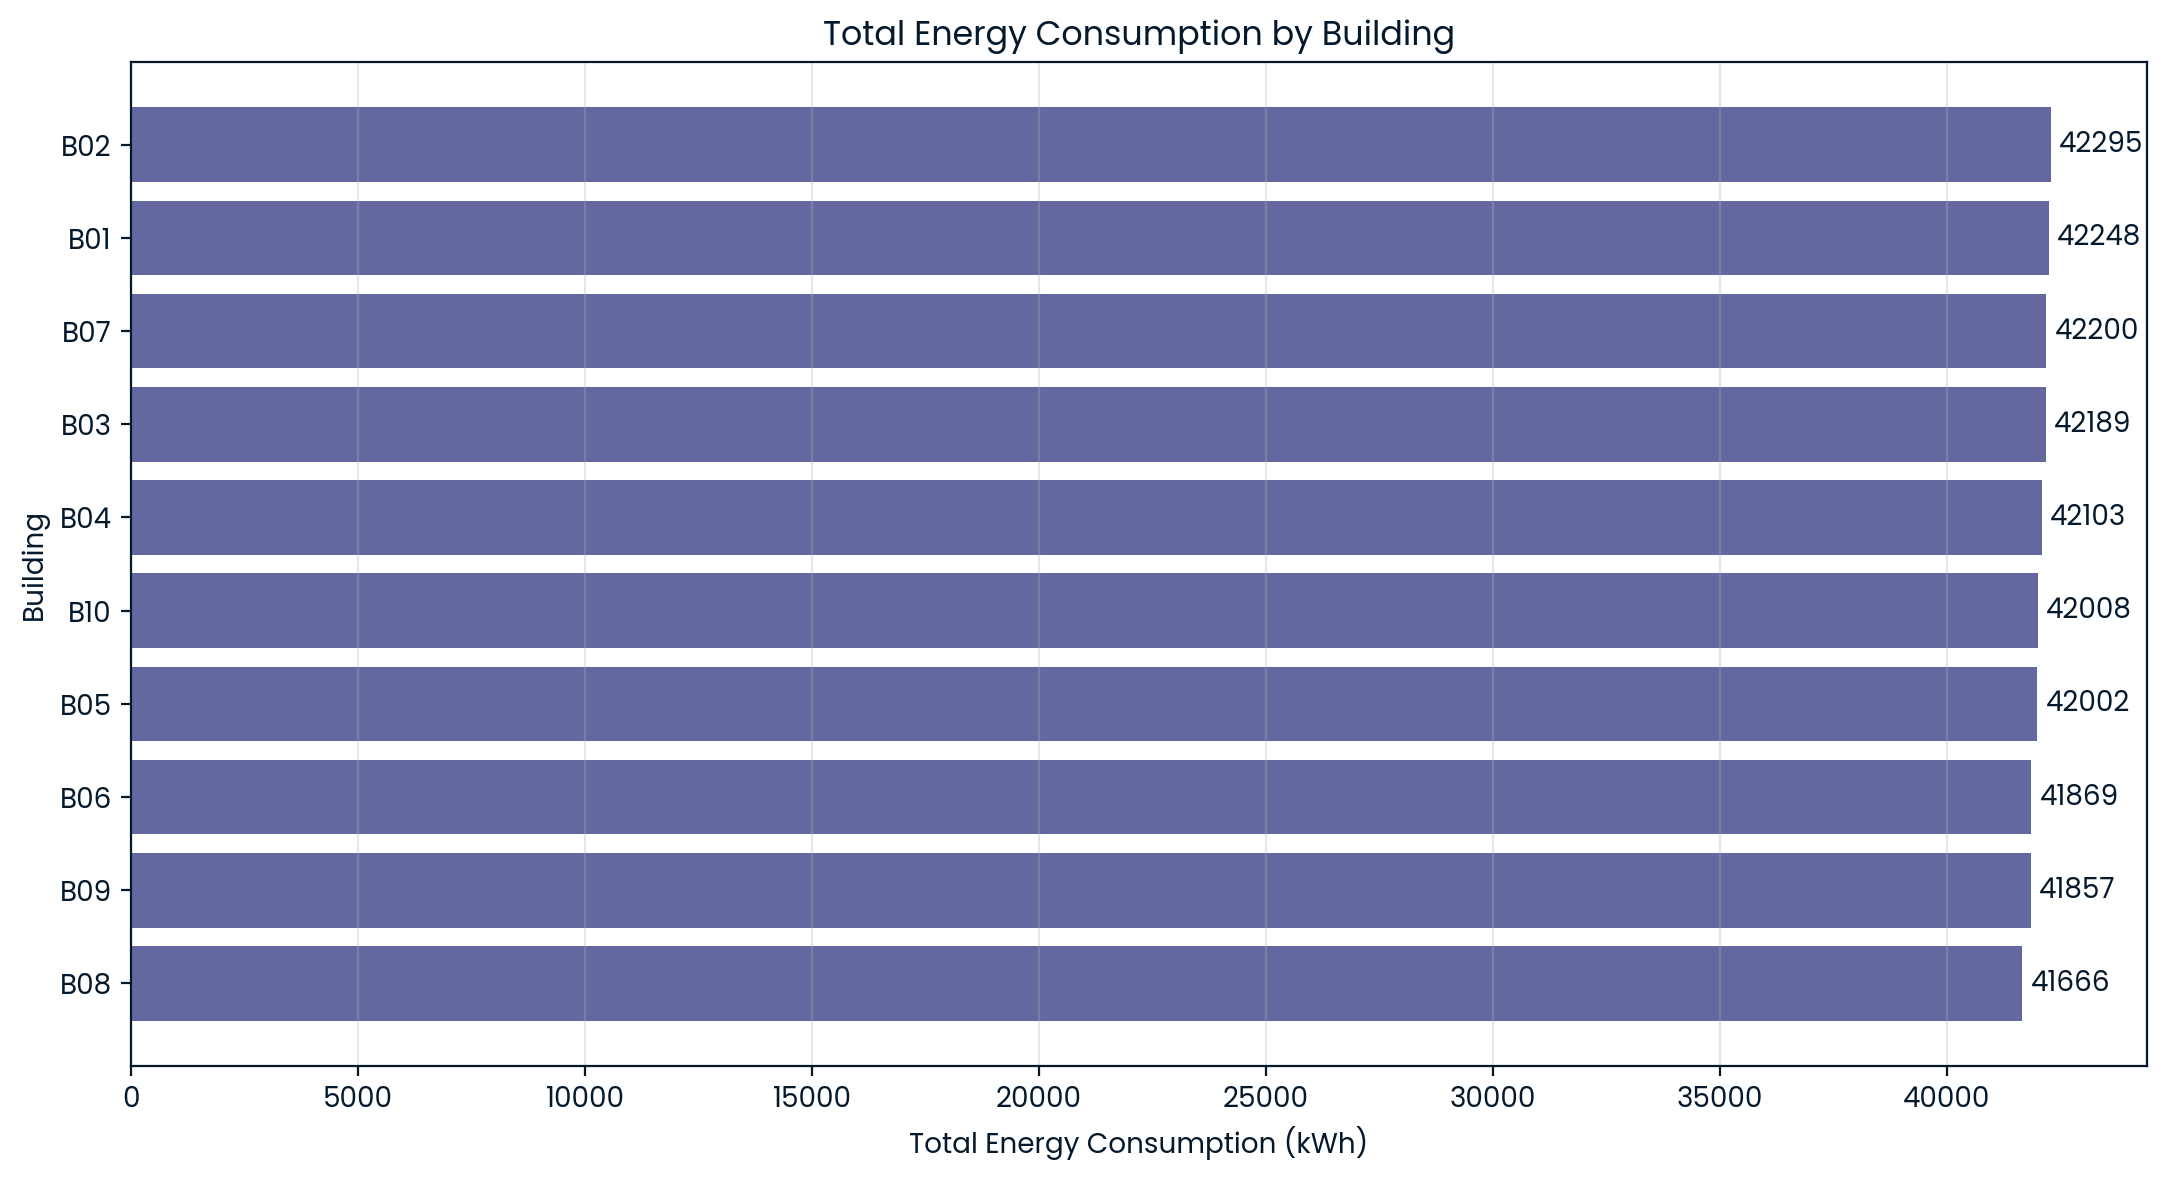

In [64]:
# Prepare building-level data for plotting
building_plot = (
    analysis_building_consumption[
        ["building_id", "total_energy_kwh"]
    ]
    .copy()
    .sort_values(
        "total_energy_kwh",
        ascending=True
    )
)

# Total energy consumption with value labels

plt.figure(figsize=(11, 6))

bars = plt.barh(
    building_plot["building_id"],
    building_plot["total_energy_kwh"]
)

plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.title(
    "Total Energy Consumption by Building"
)

plt.xlabel(
    "Total Energy Consumption (kWh)"
)

plt.ylabel(
    "Building"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

08.4 Monthly Energy Consumption Trend

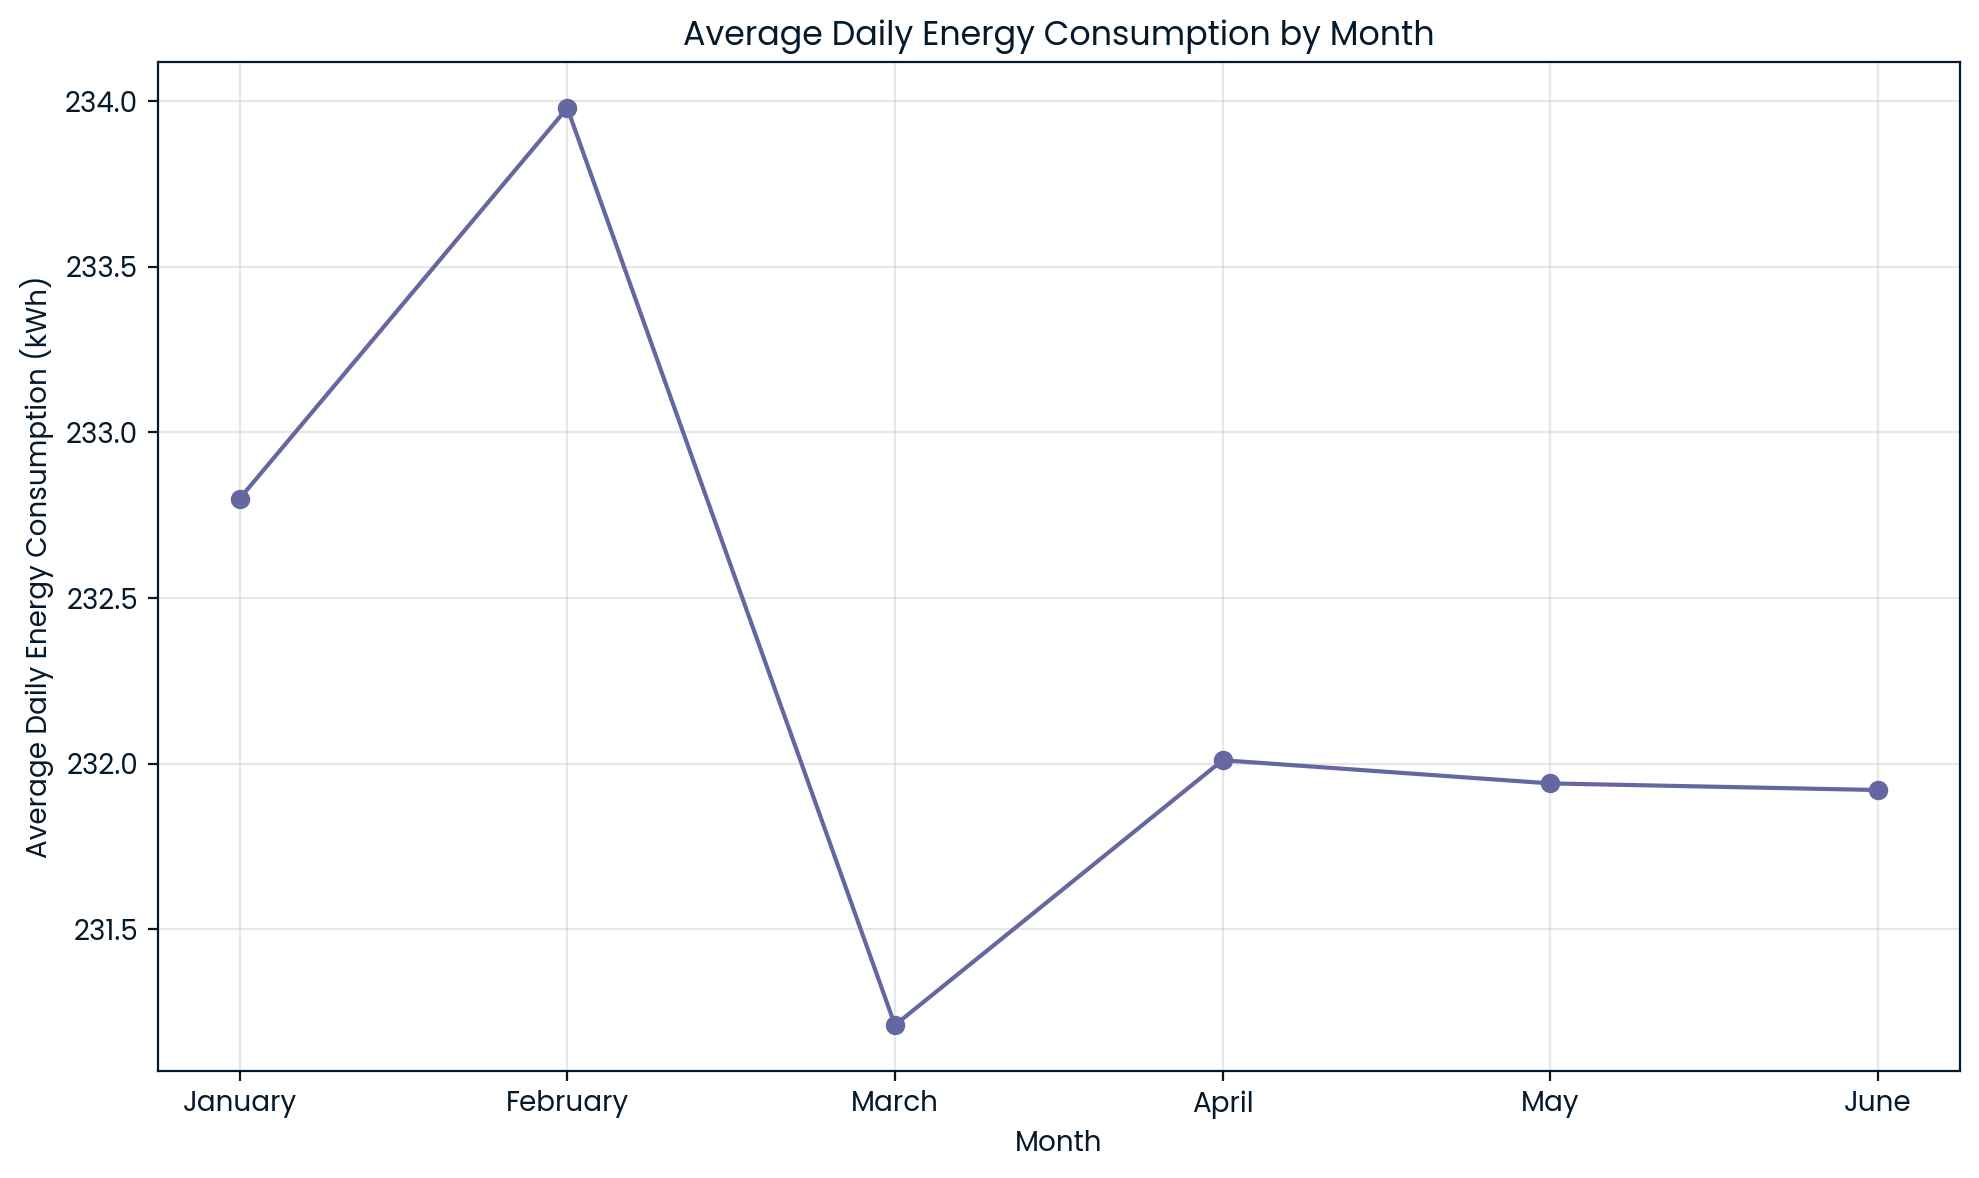

In [65]:
# Prepare monthly data for plotting
monthly_plot = (
    analysis_monthly_trend[
        [
            "month_name",
            "avg_building_daily_energy_kwh"
        ]
    ]
    .copy()
)

# Average daily energy consumption by month

monthly_plot[
    "avg_building_daily_energy_kwh"
] = pd.to_numeric(
    monthly_plot[
        "avg_building_daily_energy_kwh"
    ]
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_plot["month_name"],
    monthly_plot[
        "avg_building_daily_energy_kwh"
    ],
    marker="o"
)

plt.title(
    "Average Daily Energy Consumption by Month"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Average Daily Energy Consumption (kWh)"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

08.5 Weekday vs Weekend Consumption

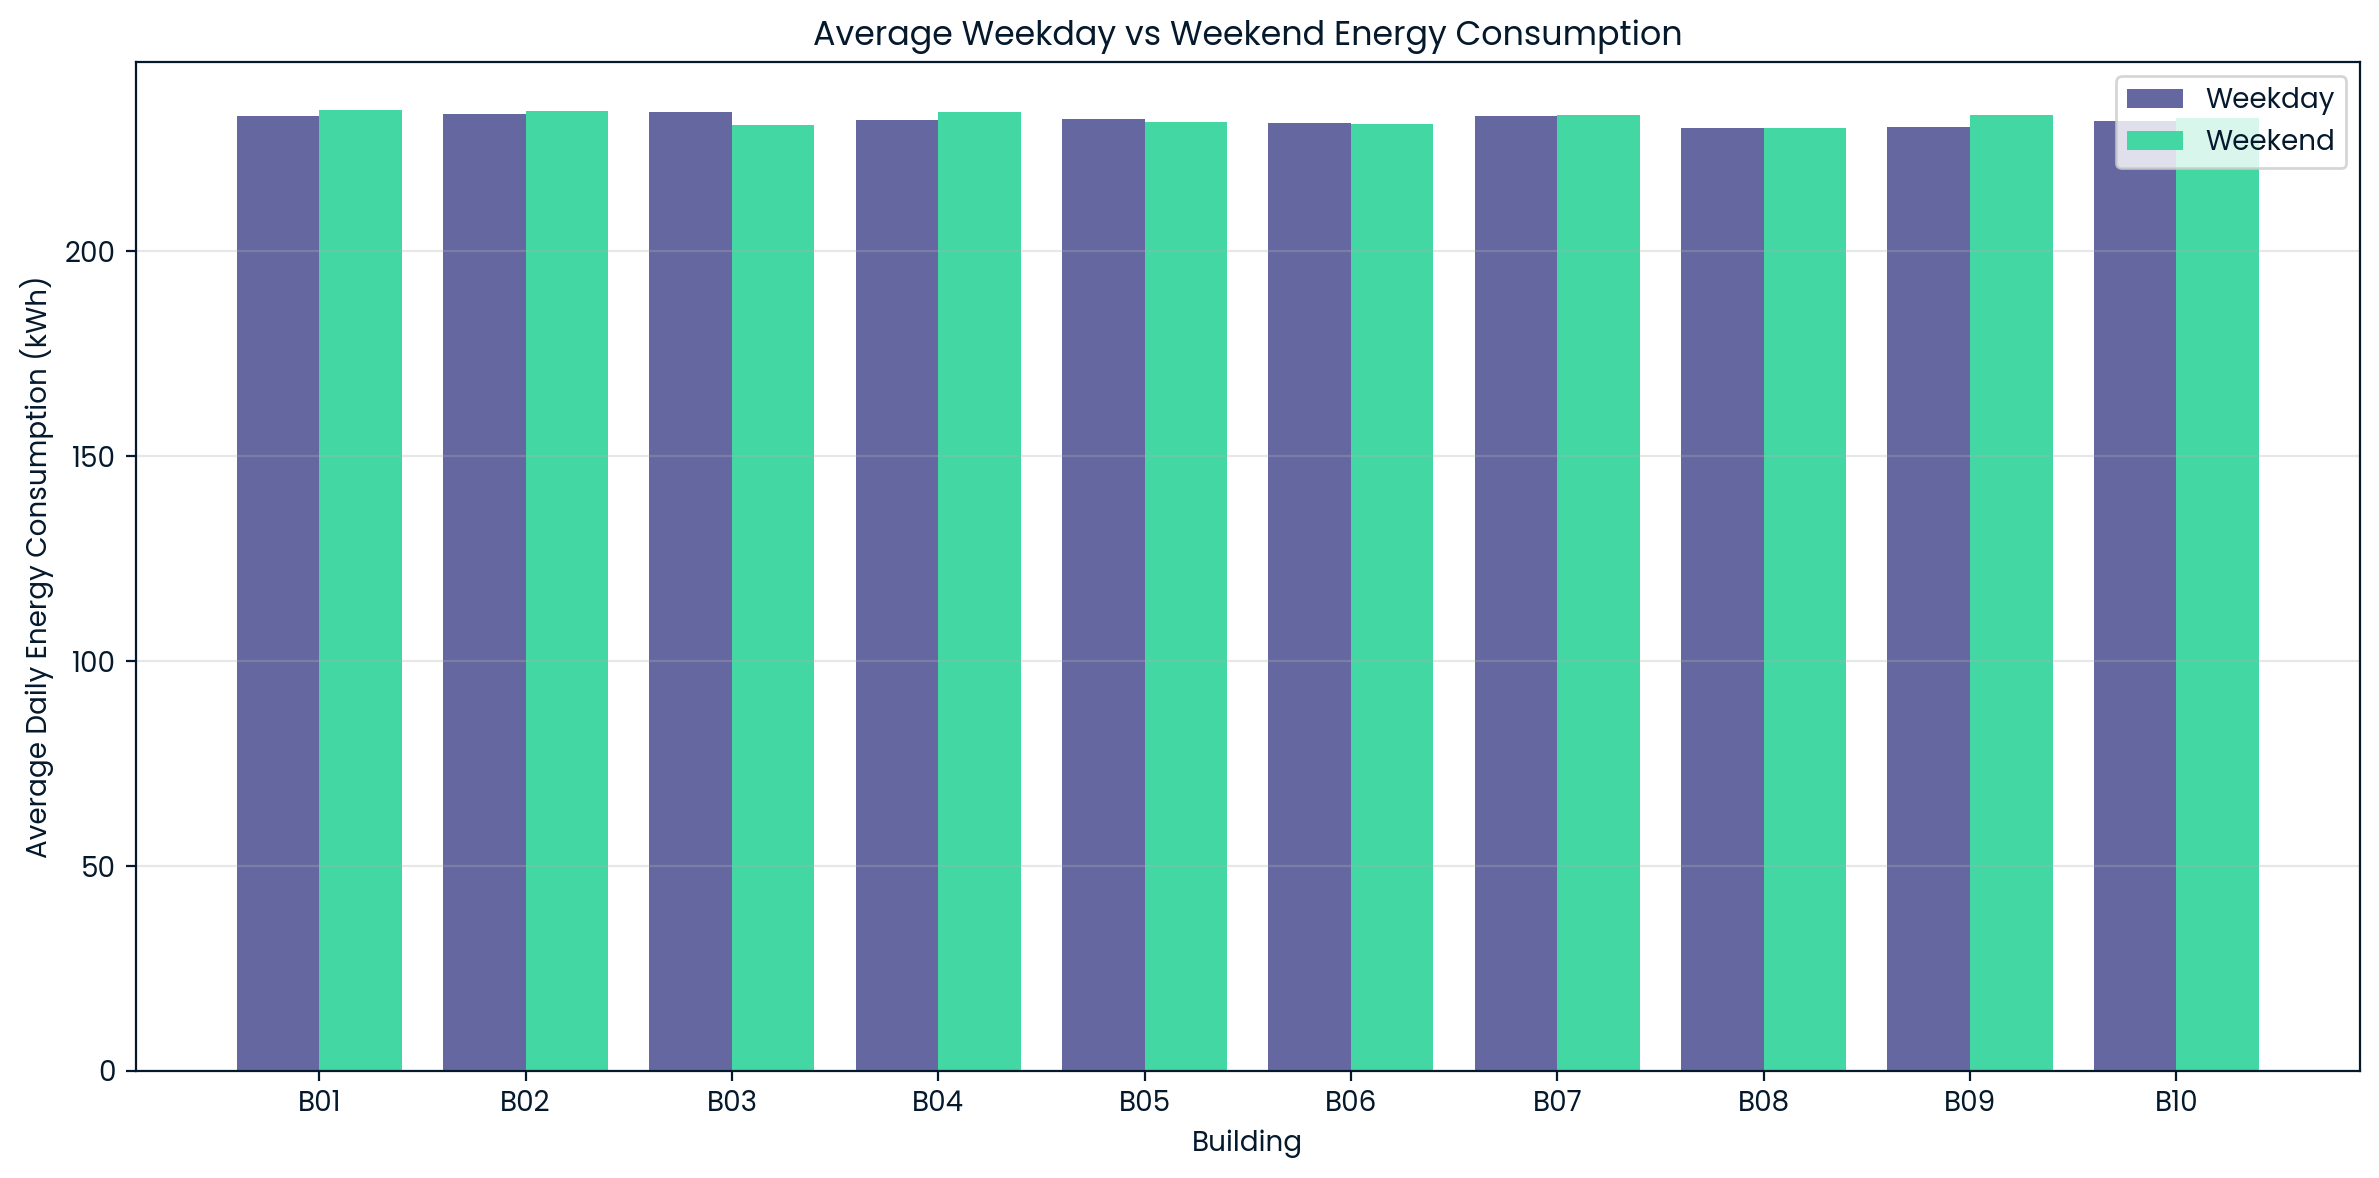

In [66]:
# Prepare weekday/weekend data

weekday_plot = (
    analysis_weekday_weekend
    .copy()
    .sort_values("building_id")
)

weekday_plot[
    "weekday_avg_energy_kwh"
] = pd.to_numeric(
    weekday_plot[
        "weekday_avg_energy_kwh"
    ]
)

weekday_plot[
    "weekend_avg_energy_kwh"
] = pd.to_numeric(
    weekday_plot[
        "weekend_avg_energy_kwh"
    ]
)

# Create x-axis positions

x = np.arange(
    len(weekday_plot)
)

width = 0.4

# Create chart

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    weekday_plot[
        "weekday_avg_energy_kwh"
    ],
    width,
    label="Weekday"
)

plt.bar(
    x + width / 2,
    weekday_plot[
        "weekend_avg_energy_kwh"
    ],
    width,
    label="Weekend"
)

plt.xticks(
    x,
    weekday_plot["building_id"]
)

plt.title(
    "Average Weekday vs Weekend Energy Consumption"
)

plt.xlabel(
    "Building"
)

plt.ylabel(
    "Average Daily Energy Consumption (kWh)"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

08.6 Hourly Energy Consumption Profile

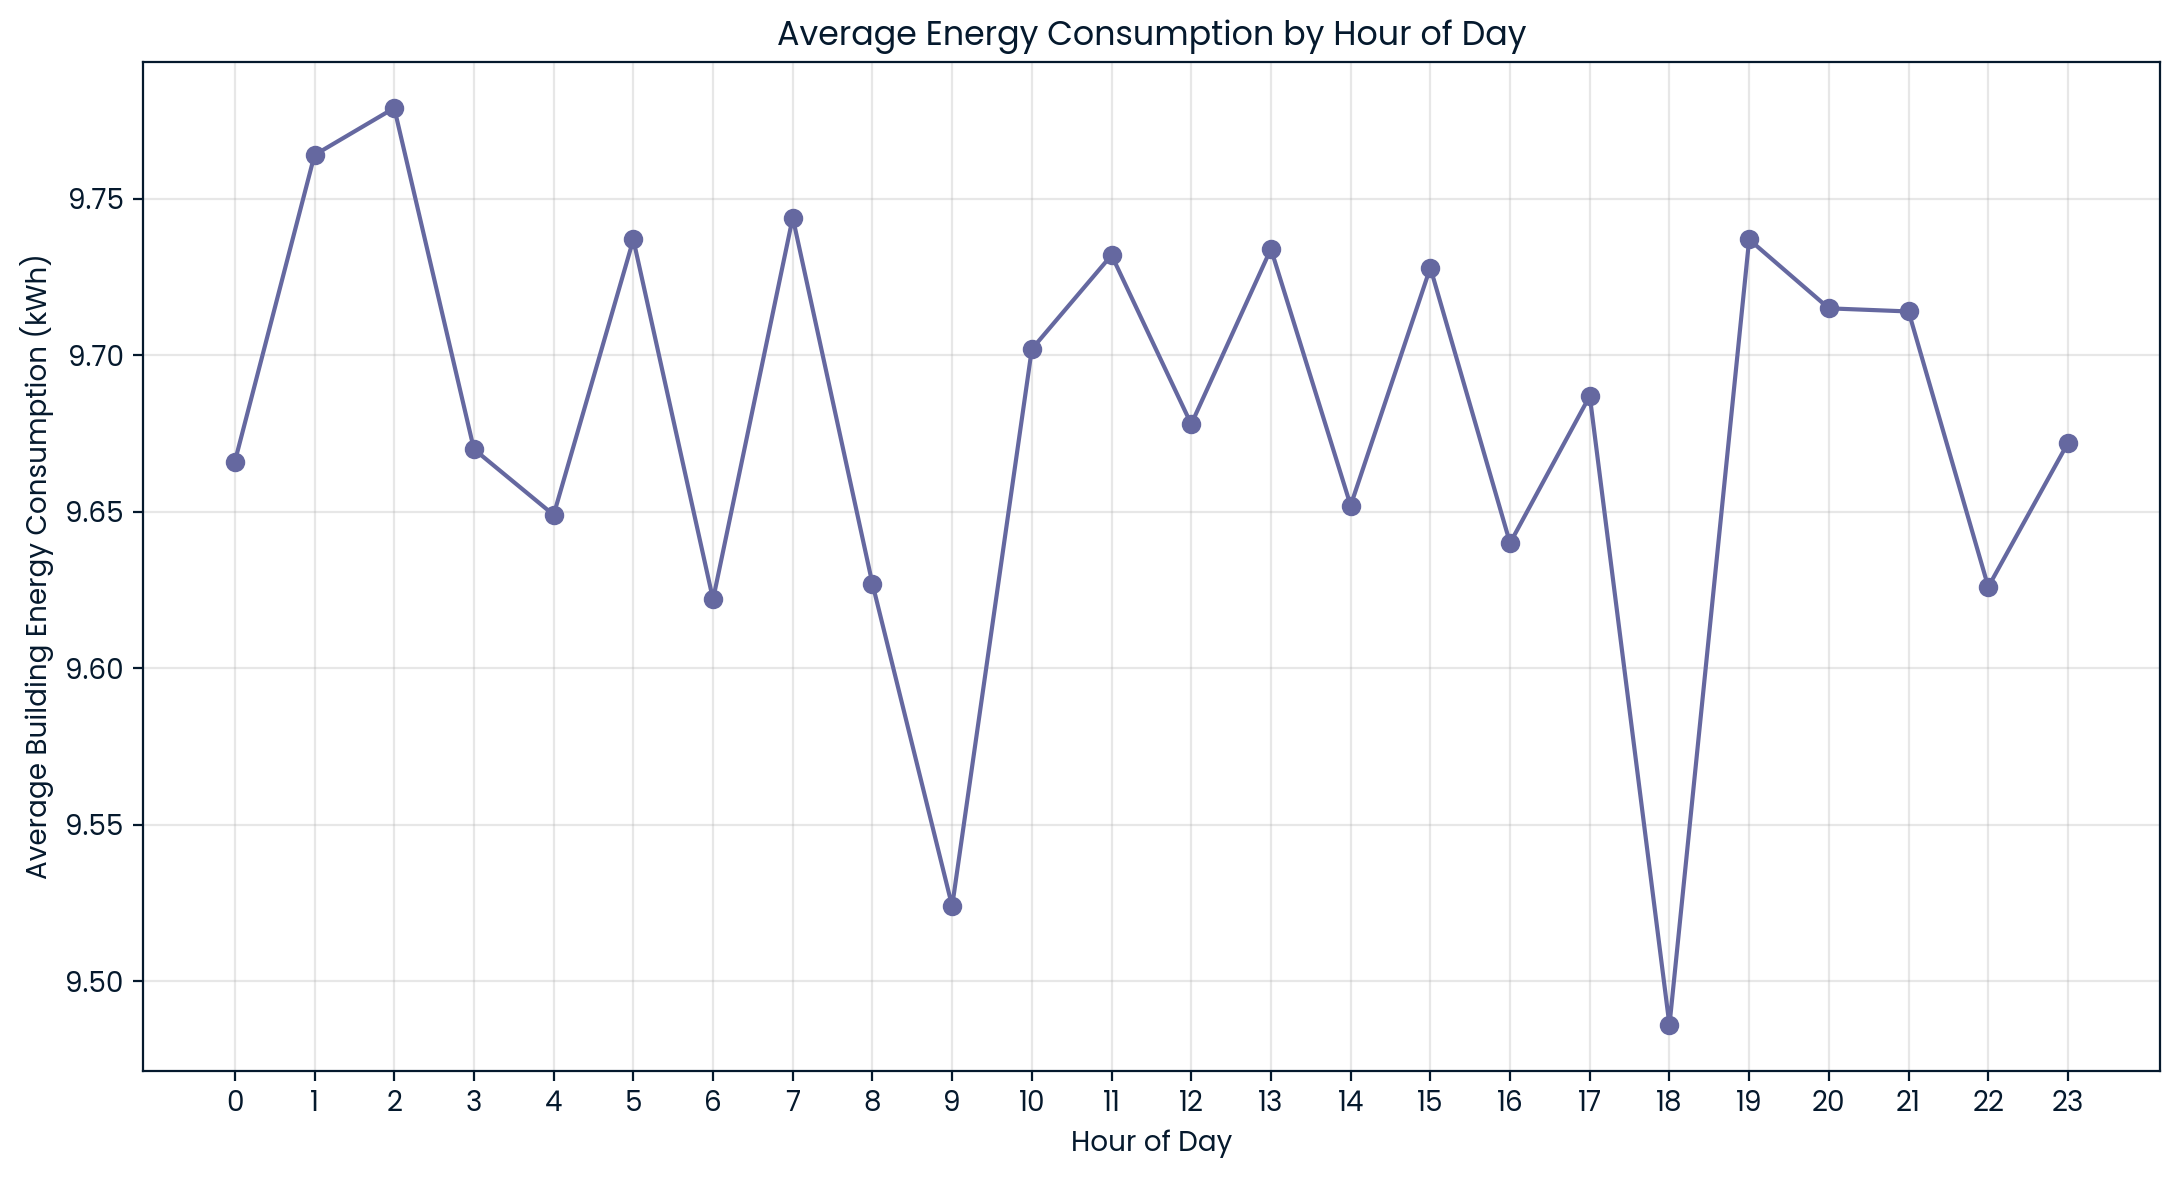

In [67]:
# Prepare hourly consumption data

hourly_plot = (
    analysis_hourly_profile
    .copy()
    .sort_values("hour")
)

hourly_plot[
    "avg_building_energy_kwh"
] = pd.to_numeric(
    hourly_plot[
        "avg_building_energy_kwh"
    ]
)

# Create chart

plt.figure(figsize=(11, 6))

plt.plot(
    hourly_plot["hour"],
    hourly_plot[
        "avg_building_energy_kwh"
    ],
    marker="o"
)

plt.title(
    "Average Energy Consumption by Hour of Day"
)

plt.xlabel(
    "Hour of Day"
)

plt.ylabel(
    "Average Building Energy Consumption (kWh)"
)

plt.xticks(
    range(0, 24)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

08.7 Top 10 Energy-Consuming Sensors

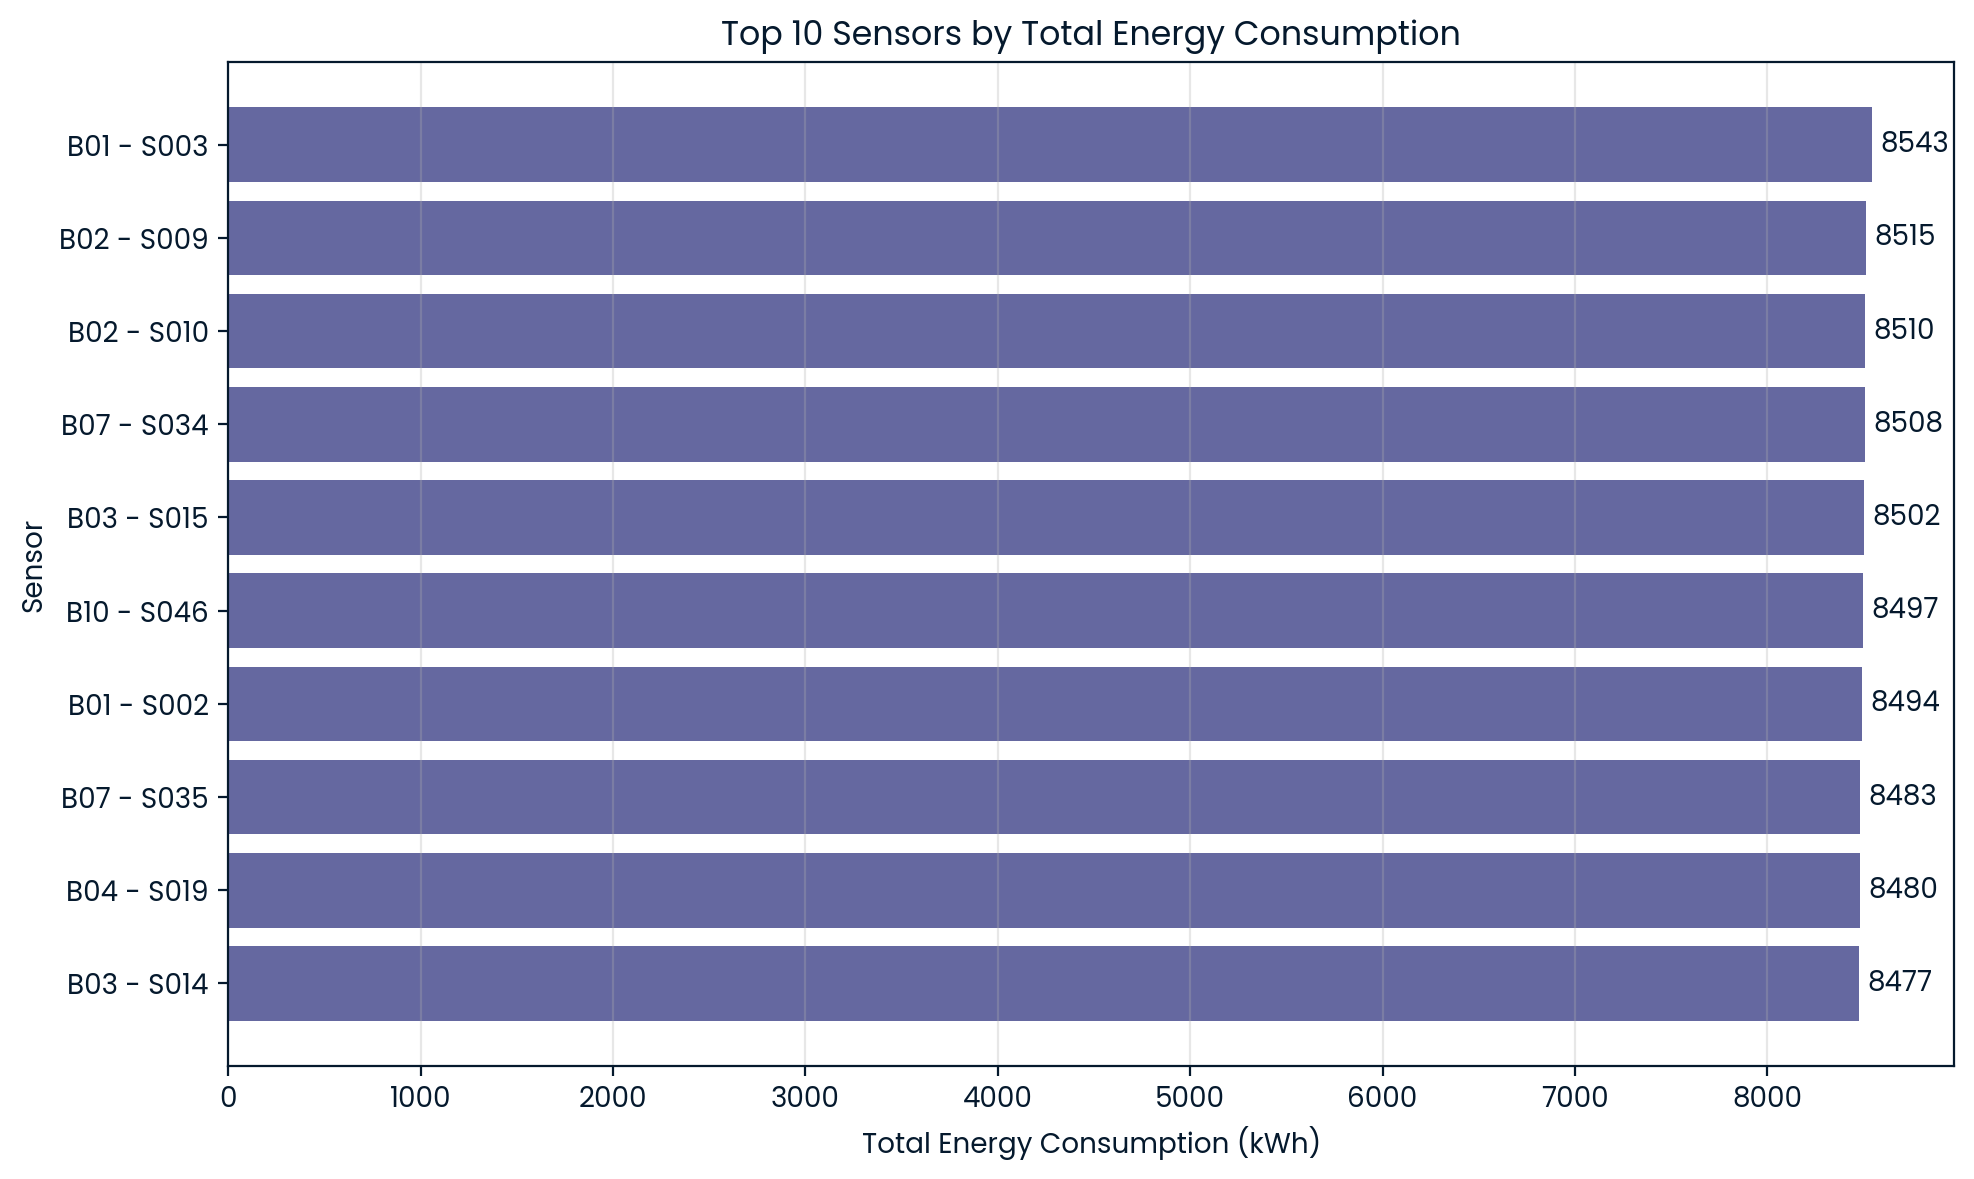

In [68]:
# Prepare top sensor data

sensor_plot = (
    analysis_sensor_consumption
    .copy()
)

sensor_plot["total_energy_kwh"] = pd.to_numeric(
    sensor_plot["total_energy_kwh"]
)

top_sensors = (
    sensor_plot
    .sort_values(
        "total_energy_kwh",
        ascending=False
    )
    .head(10)
    .sort_values(
        "total_energy_kwh"
    )
)

# Create sensor label

top_sensors["sensor_label"] = (
    top_sensors["building_id"]
    + " - "
    + top_sensors["sensor_id"]
)

# Create chart

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_sensors["sensor_label"],
    top_sensors["total_energy_kwh"]
)

plt.bar_label(
    bars,
    fmt="%.0f",
    padding=3
)

plt.title(
    "Top 10 Sensors by Total Energy Consumption"
)

plt.xlabel(
    "Total Energy Consumption (kWh)"
)

plt.ylabel(
    "Sensor"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

08.8 Sensor Data Coverage

In [69]:
# Prepare sensor coverage data

coverage_plot = (
    analysis_sensor_coverage
    .copy()
)

coverage_plot[
    "data_coverage_percent"
] = pd.to_numeric(
    coverage_plot[
        "data_coverage_percent"
    ]
)

lowest_coverage = (
    coverage_plot
    .sort_values(
        "data_coverage_percent"
    )
    .head(10)
)

lowest_coverage[
    "sensor_label"
] = (
    lowest_coverage["building_id"]
    + " - "
    + lowest_coverage["sensor_id"]
)

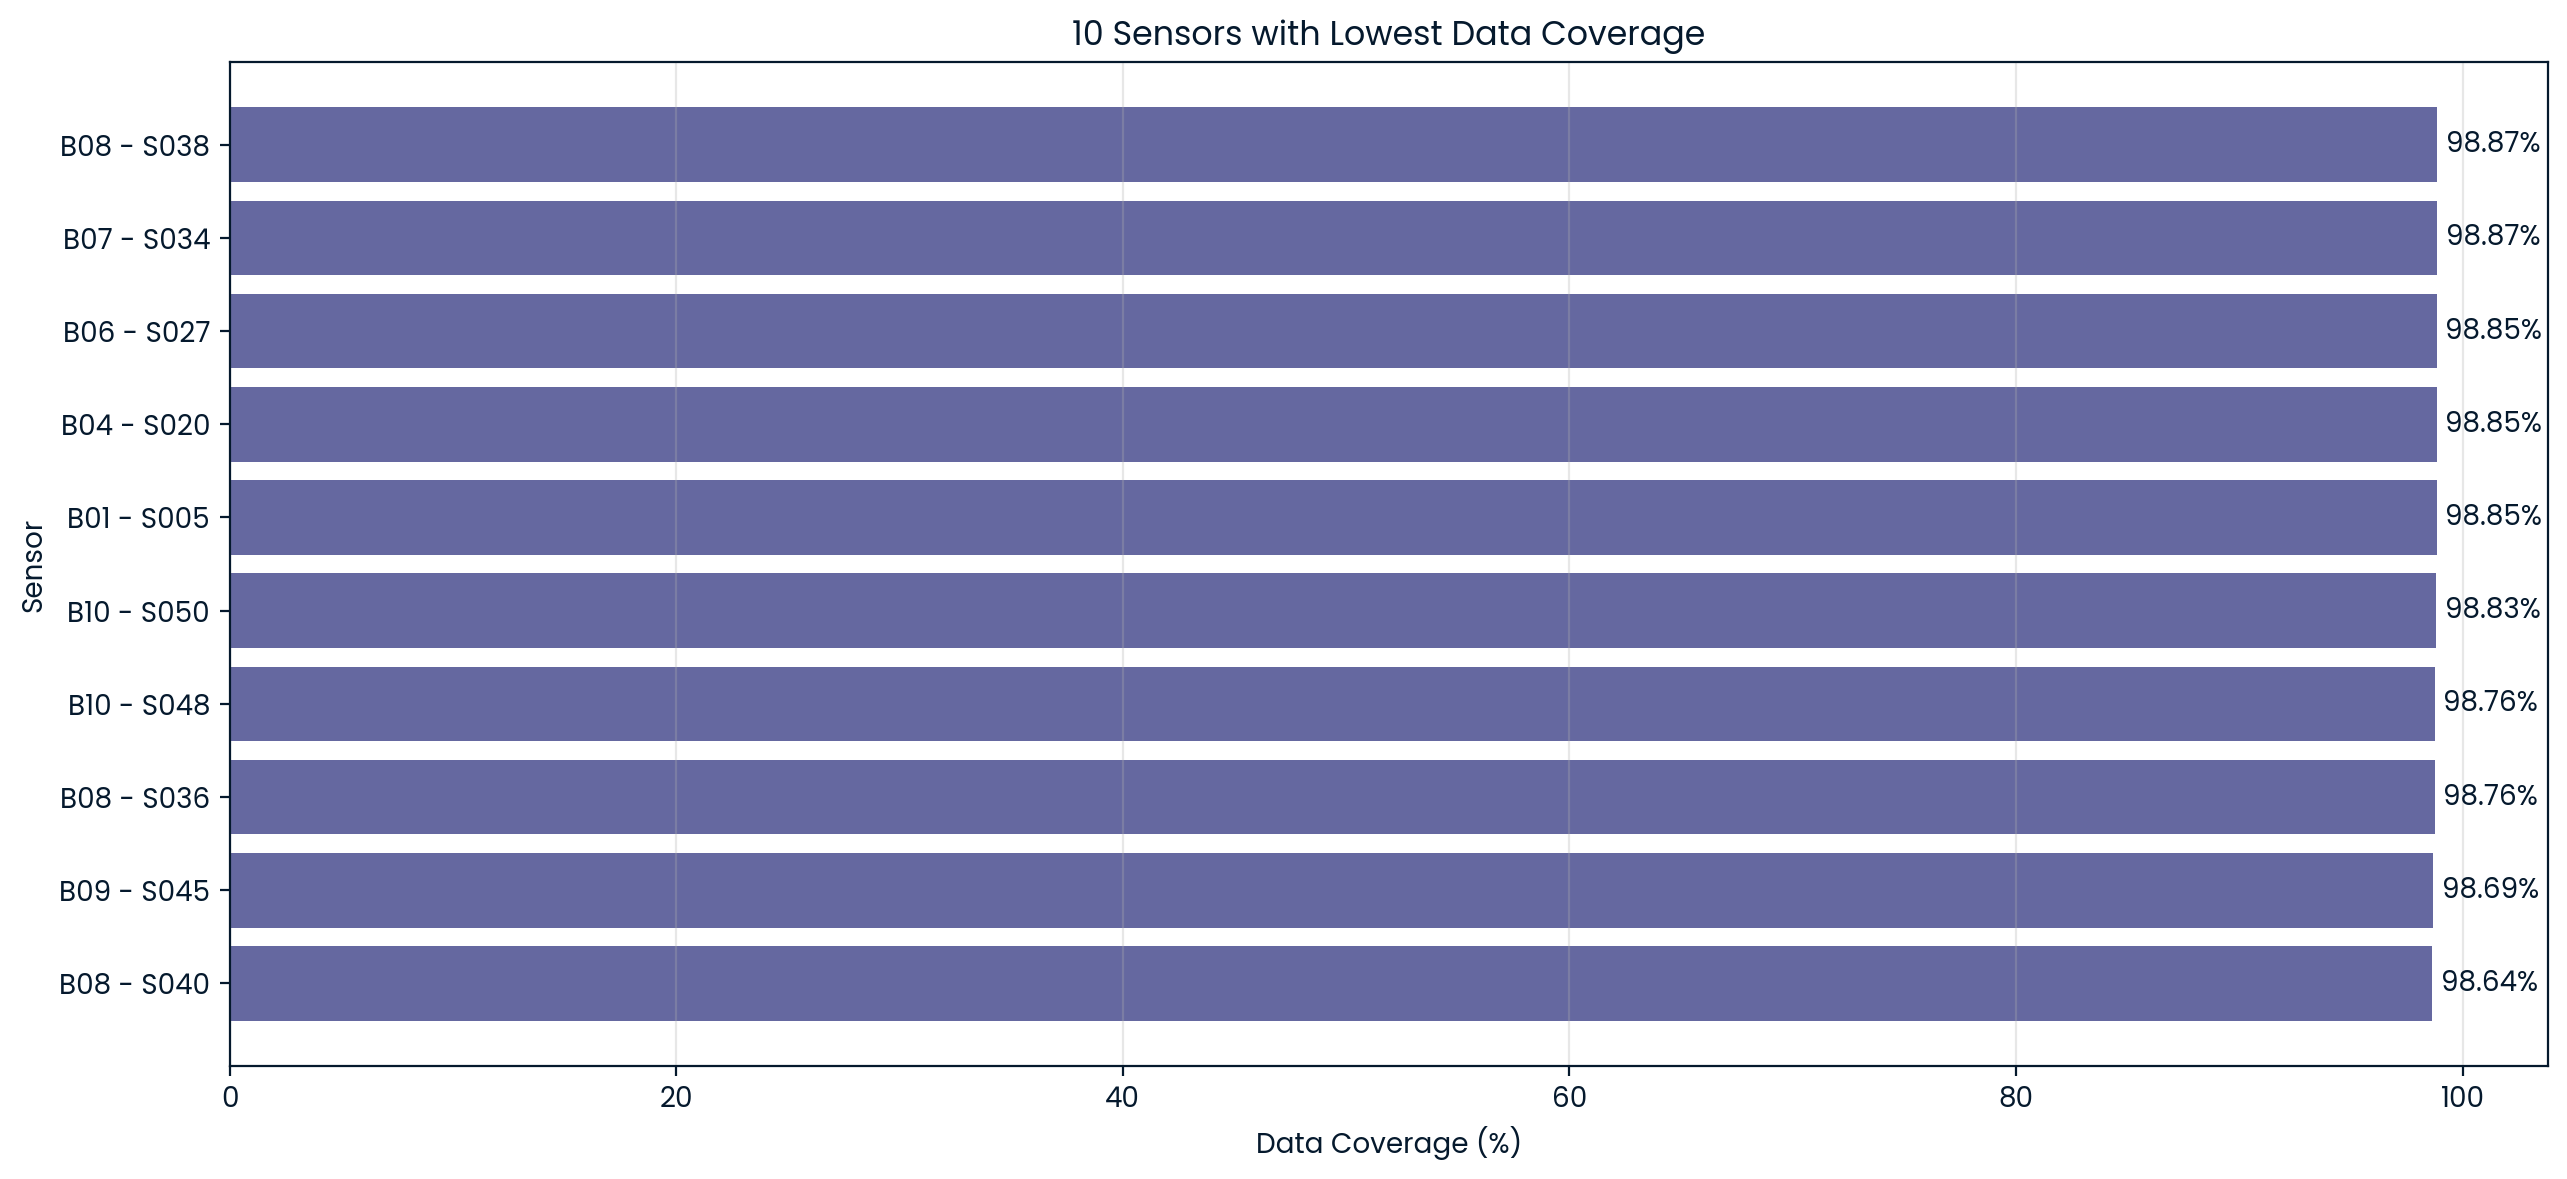

In [70]:
# Plot sensors with lowest data coverage

plt.figure(figsize=(13, 6))

bars = plt.barh(
    lowest_coverage["sensor_label"],
    lowest_coverage[
        "data_coverage_percent"
    ]
)

plt.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3
)

plt.title(
    "10 Sensors with Lowest Data Coverage"
)

plt.xlabel(
    "Data Coverage (%)"
)

plt.ylabel(
    "Sensor"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 09 - Conclusion

This project developed an end-to-end Smart Energy Monitoring Data Platform that processes simulated IoT energy readings from multiple buildings and sensors. The pipeline covered the main stages of a data engineering workflow, including raw data generation, data quality validation, cleaning, data modelling, SQL transformation, analysis, and visualisation.

The raw dataset contained over 200,000 hourly sensor readings and intentionally included missing values, duplicate records, invalid energy readings, and unrealistic voltage values. Data quality checks were used to identify these issues before a cleaning pipeline produced a validated dataset suitable for downstream processing.

The cleaned data was transformed into a star-schema data model consisting of building, sensor, and date dimensions linked to an hourly energy fact table. SQL transformations were then used to create reusable analytical datasets at hourly, daily, monthly, building, and sensor levels. The analysis demonstrated how the platform could identify building energy consumption, peak demand periods, hourly usage patterns, weekday versus weekend behaviour, sensor-level consumption, and data coverage.

The project demonstrates practical use of Python, Pandas, SQL, data cleaning, dimensional modelling, data quality testing, aggregation, CTEs, joins, and window functions. Separating the raw, cleaned, modelled, and analytical stages also reflects the layered approach commonly used in production data pipelines.

### Limitations

The primary limitation of this project is that the energy readings are synthetically generated rather than collected from real IoT devices. As a result, the consumption patterns identified during the analysis should not be interpreted as representative of real buildings. The synthetic dataset was designed primarily to demonstrate the design and operation of the data pipeline.

The current implementation also runs within a notebook environment rather than a production cloud architecture, and pipeline execution is currently manual rather than automatically scheduled.

### Future Development

A future version of the project could extend the platform into a cloud-based data engineering architecture. Raw IoT or API data could be ingested into AWS, stored in Amazon S3, processed using cloud-based ETL services, and loaded into an analytical warehouse. The pipeline could also incorporate orchestration, automated data quality testing, monitoring, and scheduled execution.

Additional improvements could include using real smart-meter or IoT datasets, introducing more realistic time-based energy consumption patterns, and creating an interactive dashboard for monitoring energy usage and operational performance.

Overall, the project provides a complete foundation for an energy-monitoring data platform and demonstrates how raw sensor data can be transformed into structured, reliable, and analysis-ready information.
